In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import json
import pickle
import os
import time
import importlib
import matplotlib.pyplot as plt

import analysis_functions as afuncs
importlib.reload(afuncs)

<module 'analysis_functions' from '/glade/u/home/cassiacai/measures/analysis_functions.py'>

In [2]:
NO_SEC_IN_1_MON = 2629740
lat_slice = slice(204, 367)
lon_slice = slice(190, 280)

In [3]:
mean_image_pop_files = [f'/glade/derecho/scratch/cassiacai/mean_image_{i}_POP.nc' for i in range(1, 8)]
mean_images_pop = [xr.open_dataset(file) for file in mean_image_pop_files]
masks_pop = [xr.where(image.__xarray_dataarray_variable__ > 0.1, 1, 0) for image in mean_images_pop]
NEPac_MHW_renamed_latlon = masks_pop[2].isel(nlat=lat_slice, nlon=lon_slice).rename({'nlat': 'nlat_t', 'nlon': 'nlon_t'})

base_paths = {
    'linear':    '/glade/work/cmendiola/data_conv_lin_trend',
    'quadratic': '/glade/work/cmendiola/data_quad_trend',
    'ensmean':   '/glade/work/cmendiola/data_ens_mean',
    'noseas':    '/glade/work/cmendiola/data_rm_seasonalcycle_mean',
}
RADIUS_INDEX_FOR_2DEG = 1

da_mhwobj_labels_by_method = {}
for method, base_path in base_paths.items():
    mhwobj_paths = [f'{base_path}/ens_{i}_mhwobj.nc' for i in range(100)]
    da_mhwobj = xr.open_mfdataset(mhwobj_paths, combine='nested', concat_dim='ensemble_member')
    da_mhwobj_labels_by_method[method] = (
        da_mhwobj.labels.sel(radius=RADIUS_INDEX_FOR_2DEG).sel(time=slice('1979-01', '2020-12')).compute()
    )
print("Labels loaded:", {m: da_mhwobj_labels_by_method[m].sizes for m in base_paths})

OVERLAP_THRESHOLD_INDEX = 4  # 50%
blob_analog_ids = {}
object_id_json_paths = {
    'linear':    'object_id_ls_greenmask_linear_corrected.json',
    'quadratic': 'object_id_ls_greenmask_quadratic_corrected.json',
    'ensmean':   'object_id_ls_greenmask_ensmean_corrected.json',
    'noseas':    'object_id_ls_greenmask_noseas_corrected.json',
}
for method, path in object_id_json_paths.items():
    with open(path, 'r') as f:
        all_thresholds = json.load(f)
    blob_analog_ids[method] = all_thresholds[OVERLAP_THRESHOLD_INDEX]

print({m: sum(len(v) for v in blob_analog_ids[m]) for m in blob_analog_ids})
print("VERIFY: linear should be 331")

Labels loaded: {'linear': Frozen({'ensemble_member': 100, 'time': 504, 'lat': 64, 'lon': 81}), 'quadratic': Frozen({'ensemble_member': 100, 'time': 504, 'lat': 64, 'lon': 81}), 'ensmean': Frozen({'ensemble_member': 100, 'time': 504, 'lat': 64, 'lon': 81}), 'noseas': Frozen({'ensemble_member': 100, 'time': 504, 'lat': 64, 'lon': 81})}
{'linear': 331, 'quadratic': 327, 'ensmean': 312, 'noseas': 343}
VERIFY: linear should be 331


In [4]:
fosi_blobs = xr.open_dataset('fosi_blobs_r2.nc').labels
object_id = 94.0
blob_times = fosi_blobs.time.where((fosi_blobs == object_id).any(dim=('lat', 'lon')), drop=True)
print(f"n_months in blob_times: {len(blob_times)} -- VERIFY: should be 20")

n_months in blob_times: 20 -- VERIFY: should be 20


In [5]:
# ============================================================
# Detrending helper (confirmed working)
# ============================================================
def detrend_term(da):
    term_nan = xr.where(da == 0., np.nan, da) * NO_SEC_IN_1_MON
    mean, trend, seasonal, notrend = afuncs.calculate_pop_grid_anomalies_trend_features(term_nan)
    return notrend


def build_padded_time_window(full_time_index, event_times, pre_post_months=2):
    """Given an event's active times, find the padded [start-2, end+2] window index."""
    first_idx = int(np.where(full_time_index.values == event_times.values[0])[0][0])
    last_idx = int(np.where(full_time_index.values == event_times.values[-1])[0][0])
    pad_start = max(0, first_idx - pre_post_months)
    pad_end = min(len(full_time_index) - 1, last_idx + pre_post_months)
    return full_time_index.isel(time=slice(pad_start, pad_end + 1))


In [6]:
# ============================================================
# FOSI: compute SUBGRID (residual), detrend, crop, mask, get padded profile
# ============================================================
fosi_heat_budget = xr.open_dataset('/glade/derecho/scratch/cassiacai/fosi_heat_budget_155m.nc')
fosi_heat_budget['SUBGRID'] = fosi_heat_budget['TEND_TEMP'] - (
    fosi_heat_budget['TOTADV'] + fosi_heat_budget['SHF_depth'] + fosi_heat_budget['QSW_3D']
)

fosi_hb_detrended = {}
for term in ['TOTADV', 'SHF_depth', 'QSW_3D', 'SUBGRID', 'TEND_TEMP']:
    notrend = detrend_term(fosi_heat_budget[term])
    key = 'TOT_ADV' if term == 'TOTADV' else term
    fosi_hb_detrended[key] = notrend

fosi_hb_cropped = {term: da.isel(nlat_t=lat_slice, nlon_t=lon_slice) for term, da in fosi_hb_detrended.items()}
fosi_hb_masked = {term: da.where(NEPac_MHW_renamed_latlon == 1) for term, da in fosi_hb_cropped.items()}

padded_times_fosi = build_padded_time_window(fosi_hb_masked['TOT_ADV'].time, blob_times)
fosi_hb_profile = {
    term: da.sel(time=padded_times_fosi).mean(dim=('nlat_t', 'nlon_t')).compute()
    for term, da in fosi_hb_masked.items()
}
print({term: (float(ts.min()), float(ts.max())) for term, ts in fosi_hb_profile.items()})


{'TOT_ADV': (-1.9189894364378537, 2.3374321488967467), 'SHF_depth': (-4.990679540345742, 4.663633052585285), 'QSW_3D': (-0.7715706456049386, 0.7638532699842709), 'SUBGRID': (-2.6647983800899517, 4.331895032176939), 'TEND_TEMP': (-2.1350142038697943, 2.4867183875509213)}


In [9]:
import numpy as np

def phase_split_positive_only(term_profiles, pre_post_months=2, min_months_for_5phase=8):
    """
    Same phase structure as phase_split_adaptive, but peak-tendency is defined
    as the month of maximum POSITIVE tendency (argmax, not argmax of |tendency|),
    forced regardless of whether a larger-magnitude negative month exists.
    """
    tend_temp = term_profiles['TEND_TEMP']
    n_total = len(tend_temp.time)
    core_start = pre_post_months
    core_end = n_total - pre_post_months
    core_length = core_end - core_start

    if core_length < min_months_for_5phase:
        return None, 3, None  # skip 3-phase events for this comparison

    core_tend = tend_temp.isel(time=slice(core_start, core_end))
    peak_idx_within_core = int(core_tend.values.argmax())  # MAX POSITIVE, not abs
    peak_idx_global = core_start + peak_idx_within_core
    has_prepeak = peak_idx_global > core_start
    has_postpeak = peak_idx_global < core_end - 1

    result = {}
    for term, ts in term_profiles.items():
        result[term] = {
            'Pre-MHW':  float(ts.isel(time=slice(0, core_start)).mean()),
            'pre-peak': float(ts.isel(time=slice(core_start, peak_idx_global)).mean()) if has_prepeak else np.nan,
            'peak-tendency': float(ts.isel(time=peak_idx_global)),
            'post-peak': float(ts.isel(time=slice(peak_idx_global + 1, core_end)).mean()) if has_postpeak else np.nan,
            'Post-MHW': float(ts.isel(time=slice(-pre_post_months, None)).mean()),
        }
    peak_date = tend_temp.time.values[peak_idx_global]
    return result, 5, peak_date


# ============================================================
# Apply to ALL 242 five-phase analogs (not just warming-peak ones)
# ============================================================
hb_phases_positive_only = {}
for key in keys_5phase:
    phases, n_phases, peak_date = phase_split_positive_only(heat_budget_profiles_all[key]['terms'])
    if phases is not None:
        hb_phases_positive_only[key] = {'phases': phases, 'n_phases': n_phases, 'peak_date': peak_date}

print(f"Positive-only peak, n={len(hb_phases_positive_only)}")

composite_positive_only = composite_phase_group(
    list(hb_phases_positive_only.keys()), hb_phases_positive_only, PHASE_NAMES_5
)

# ============================================================
# Compare: magnitude-based pooled, magnitude-based warming-only,
# vs. this new positive-only-forced composite
# ============================================================
print("\n=== Comparison at peak-tendency: pooled (magnitude) vs warming-only (magnitude) vs positive-only-forced ===")
for term in TERMS:
    pooled_mean, pooled_std, pooled_n = composite_all_5phase[term]['peak-tendency']
    warm_mean, warm_std, warm_n = composite_warming[term]['peak-tendency']
    posonly_mean, posonly_std, posonly_n = composite_positive_only[term]['peak-tendency']
    print(f"{term}: pooled(n={pooled_n})={pooled_mean:.2f}±{pooled_std:.2f} | "
          f"warming-only(n={warm_n})={warm_mean:.2f}±{warm_std:.2f} | "
          f"positive-forced(n={posonly_n})={posonly_mean:.2f}±{posonly_std:.2f}")

Positive-only peak, n=242

=== Comparison at peak-tendency: pooled (magnitude) vs warming-only (magnitude) vs positive-only-forced ===
TEND_TEMP: pooled(n=242)=-0.35±2.52 | warming-only(n=113)=2.25±0.55 | positive-forced(n=242)=2.00±0.57
TOT_ADV: pooled(n=242)=0.21±1.74 | warming-only(n=113)=-0.11±1.46 | positive-forced(n=242)=0.03±1.47
SHF_depth: pooled(n=242)=-0.82±4.83 | warming-only(n=113)=4.14±1.19 | positive-forced(n=242)=3.67±1.15
QSW_3D: pooled(n=242)=0.15±0.83 | warming-only(n=113)=0.68±0.73 | positive-forced(n=242)=0.74±0.68
SUBGRID: pooled(n=242)=0.11±3.20 | warming-only(n=113)=-2.46±1.72 | positive-forced(n=242)=-2.45±1.75


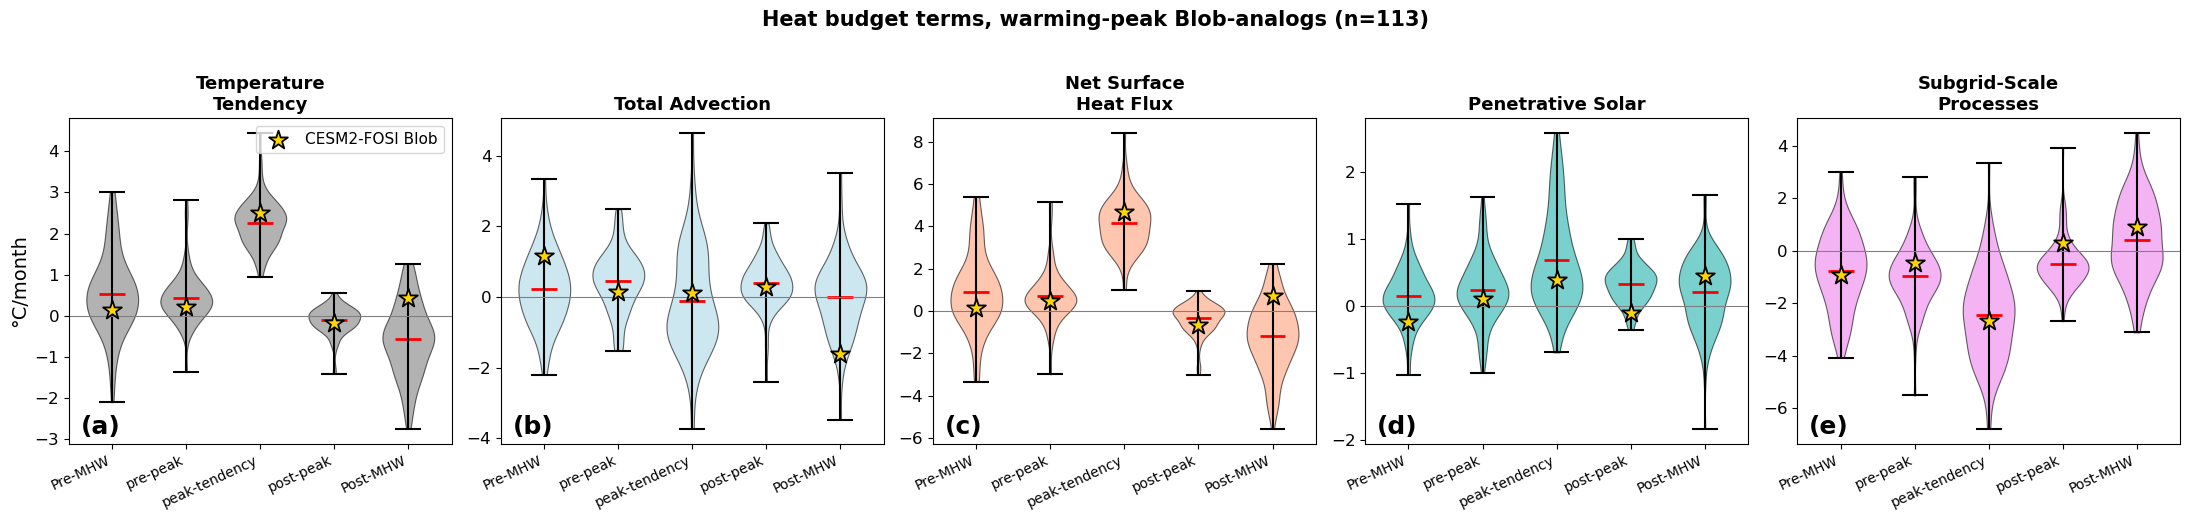

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Figure 2a-e: Heat budget term violins, WARMING-PEAK analogs only,
# with the Blob (warming-peak event) marked as a gold star
# ============================================================
def plot_term_panel_violin_with_blob(ax, term, phase_names, keys, hb_phases_dict, blob_values, title, color):
    individual_vals = get_individual_values_by_phase(keys, hb_phases_dict, term, phase_names)
    data_for_violin = [individual_vals[p] for p in phase_names]
    positions = np.arange(len(phase_names))

    parts = ax.violinplot(data_for_violin, positions=positions, showmeans=True, showmedians=False, widths=0.7)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.6)
        pc.set_edgecolor('k')
        pc.set_linewidth(0.8)
    parts['cmeans'].set_color('red')
    parts['cmeans'].set_linewidth(2)
    parts['cbars'].set_color('k')
    parts['cmins'].set_color('k')
    parts['cmaxes'].set_color('k')

    for i, phase in enumerate(phase_names):
        if phase in blob_values and not np.isnan(blob_values[phase]):
            ax.scatter(i, blob_values[phase], color='gold', edgecolor='black', s=200,
                       marker='*', zorder=20, linewidth=1.3, label='CESM2-FOSI Blob' if i == 0 else None)

    ax.axhline(0, color='gray', linewidth=0.8)
    ax.set_xticks(positions)
    ax.set_xticklabels(phase_names, fontsize=10, rotation=25, ha='right')
    ax.set_title(title, fontsize=13, fontweight='bold')


PHASE_NAMES_5 = ['Pre-MHW', 'pre-peak', 'peak-tendency', 'post-peak', 'Post-MHW']
term_titles = {
    'TEND_TEMP': 'Temperature\nTendency', 'TOT_ADV': 'Total Advection',
    'SHF_depth': 'Net Surface\nHeat Flux', 'QSW_3D': 'Penetrative Solar', 'SUBGRID': 'Subgrid-Scale\nProcesses',
}
term_colors = {
    'TEND_TEMP': 'gray', 'TOT_ADV': 'lightblue',
    'SHF_depth': 'lightsalmon', 'QSW_3D': 'lightseagreen', 'SUBGRID': 'violet',
}
panel_letters = ['(a)', '(b)', '(c)', '(d)', '(e)']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, term, letter in zip(axes, TERMS, panel_letters):
    plot_term_panel_violin_with_blob(ax, term, PHASE_NAMES_5, warming_keys, hb_phases_all,
                                      blob_values_by_term_5[term], term_titles[term], term_colors[term])
    ax.text(0.03, 0.03, letter, transform=ax.transAxes, fontsize=18, fontweight='bold')
    ax.tick_params(axis='y', labelsize=12)
    if ax == axes[0]:
        ax.set_ylabel('°C/month', fontsize=14)
        ax.legend(fontsize=11, loc='upper right', frameon=True)

fig.suptitle(f'Heat budget terms, warming-peak Blob-analogs (n={len(warming_keys)})', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('Figure2_a-e_heat_budget_warming_peak.png', dpi=300, bbox_inches='tight')
plt.show()

Shared y-axis range: -7.46 to 9.26


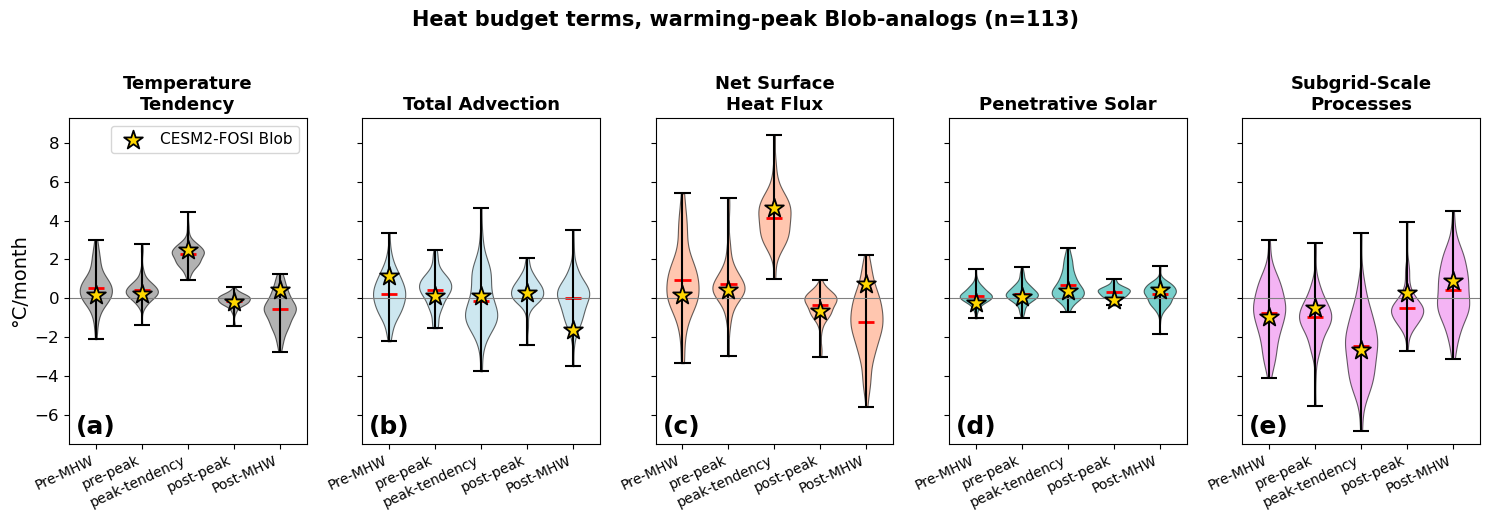

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Compute a shared y-axis range across all five terms
# (based on warming-peak analog values + Blob values)
# ============================================================
all_values_for_range = []
for term in TERMS:
    for phase in PHASE_NAMES_5:
        vals = get_individual_values_by_phase(warming_keys, hb_phases_all, term, [phase])[phase]
        all_values_for_range.extend(vals)
    blob_val = blob_values_by_term_5[term]
    all_values_for_range.extend([v for v in blob_val.values() if not np.isnan(v)])

y_min = min(all_values_for_range) * 1.1 if min(all_values_for_range) < 0 else min(all_values_for_range) * 0.9
y_max = max(all_values_for_range) * 1.1
print(f"Shared y-axis range: {y_min:.2f} to {y_max:.2f}")


# ============================================================
# Figure 2a-e: Heat budget term violins, warming-peak analogs,
# SHARED y-axis across all five panels
# ============================================================
def plot_term_panel_violin_with_blob(ax, term, phase_names, keys, hb_phases_dict, blob_values, title, color):
    individual_vals = get_individual_values_by_phase(keys, hb_phases_dict, term, phase_names)
    data_for_violin = [individual_vals[p] for p in phase_names]
    positions = np.arange(len(phase_names))

    parts = ax.violinplot(data_for_violin, positions=positions, showmeans=True, showmedians=False, widths=0.7)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.6)
        pc.set_edgecolor('k')
        pc.set_linewidth(0.8)
    parts['cmeans'].set_color('red')
    parts['cmeans'].set_linewidth(2)
    parts['cbars'].set_color('k')
    parts['cmins'].set_color('k')
    parts['cmaxes'].set_color('k')

    for i, phase in enumerate(phase_names):
        if phase in blob_values and not np.isnan(blob_values[phase]):
            ax.scatter(i, blob_values[phase], color='gold', edgecolor='black', s=200,
                       marker='*', zorder=20, linewidth=1.3, label='CESM2-FOSI Blob' if i == 0 else None)

    ax.axhline(0, color='gray', linewidth=0.8)
    ax.set_xticks(positions)
    ax.set_xticklabels(phase_names, fontsize=10, rotation=25, ha='right')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylim(y_min, y_max)  # SHARED across all panels


fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for ax, term, letter in zip(axes, TERMS, panel_letters):
    plot_term_panel_violin_with_blob(ax, term, PHASE_NAMES_5, warming_keys, hb_phases_all,
                                      blob_values_by_term_5[term], term_titles[term], term_colors[term])
    ax.text(0.03, 0.03, letter, transform=ax.transAxes, fontsize=18, fontweight='bold')
    ax.tick_params(axis='y', labelsize=12)
    if ax == axes[0]:
        ax.set_ylabel('°C/month', fontsize=14)
        ax.legend(fontsize=11, loc='upper right', frameon=True)
    else:
        ax.set_yticklabels([])  # avoid repeating y-axis labels on every panel

fig.suptitle(f'Heat budget terms, warming-peak Blob-analogs (n={len(warming_keys)})', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('Figure2_a-e_heat_budget_warming_peak_shared_yaxis.png', dpi=300, bbox_inches='tight')
plt.show()

Shared y-axis range (all terms, both rows): -10.75 to 9.26


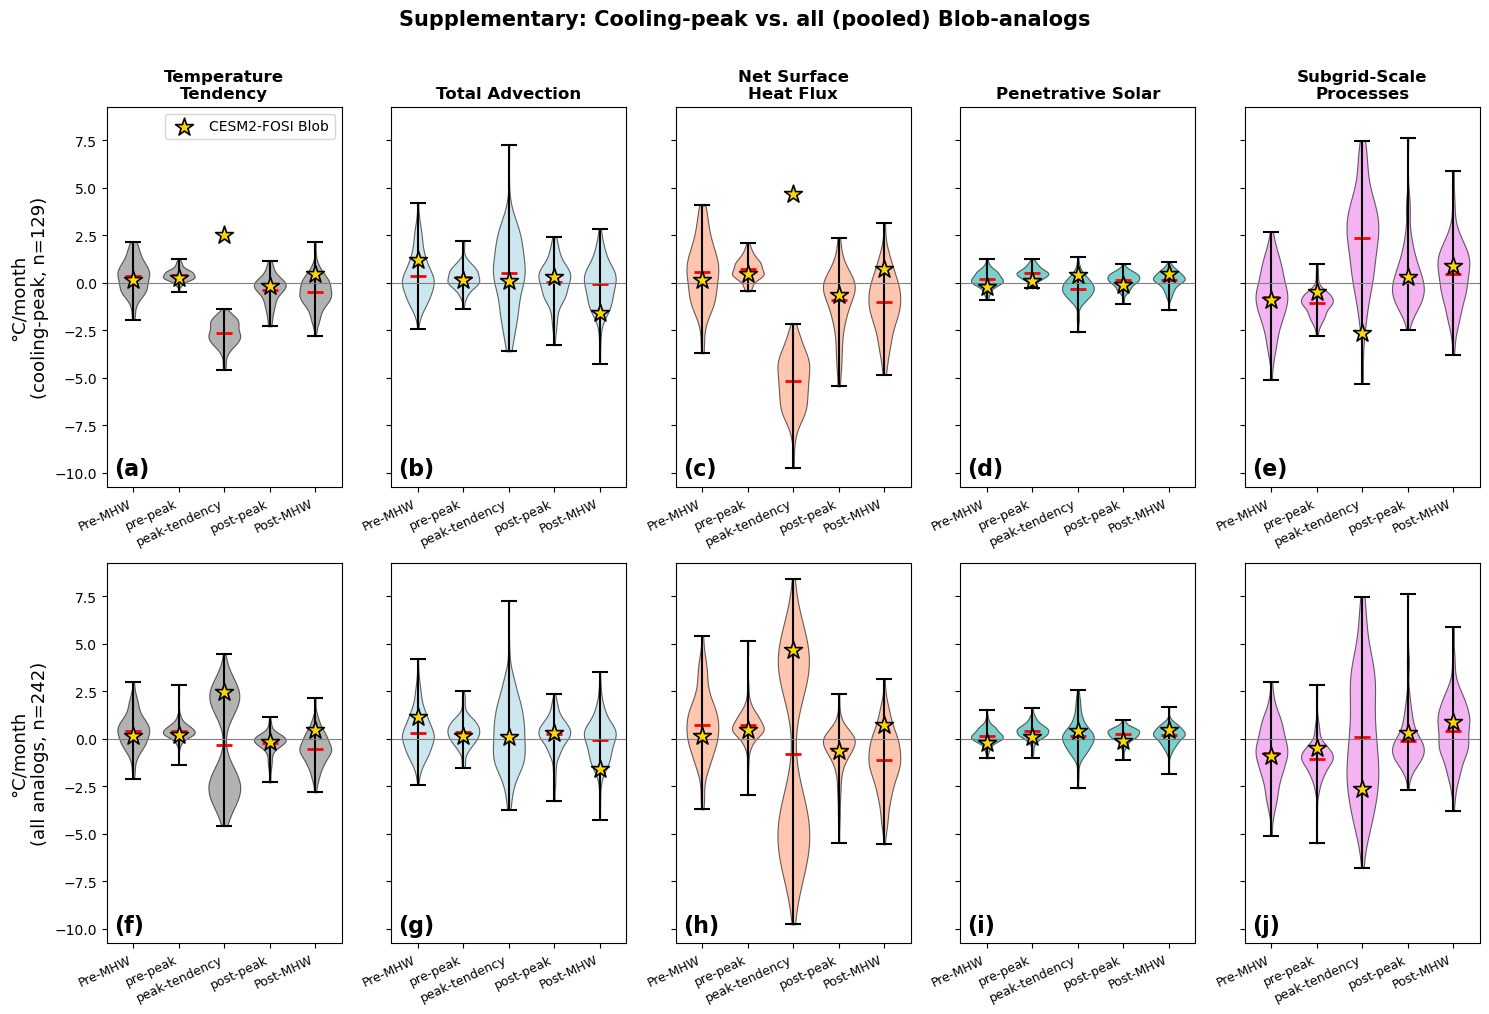

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Compute ONE shared y-axis across ALL FIVE terms, BOTH rows
# ============================================================
all_terms = ['TEND_TEMP', 'TOT_ADV', 'SHF_depth', 'QSW_3D', 'SUBGRID']

def get_shared_range_all_terms(keys, hb_phases_dict, terms_list, blob_values_dict):
    all_vals = []
    for term in terms_list:
        for phase in PHASE_NAMES_5:
            vals = get_individual_values_by_phase(keys, hb_phases_dict, term, [phase])[phase]
            all_vals.extend(vals)
        blob_val = blob_values_dict[term]
        all_vals.extend([v for v in blob_val.values() if not np.isnan(v)])
    return min(all_vals), max(all_vals)

y_min_cooling, y_max_cooling = get_shared_range_all_terms(cooling_keys, hb_phases_all, all_terms, blob_values_by_term_5)
y_min_all, y_max_all = get_shared_range_all_terms(keys_5phase, hb_phases_all, all_terms, blob_values_by_term_5)

y_min = min(y_min_cooling, y_min_all) * 1.1
y_max = max(y_max_cooling, y_max_all) * 1.1
print(f"Shared y-axis range (all terms, both rows): {y_min:.2f} to {y_max:.2f}")


def plot_term_panel_violin_with_blob(ax, term, phase_names, keys, hb_phases_dict, blob_values, title, color, ylim):
    individual_vals = get_individual_values_by_phase(keys, hb_phases_dict, term, phase_names)
    data_for_violin = [individual_vals[p] for p in phase_names]
    positions = np.arange(len(phase_names))

    parts = ax.violinplot(data_for_violin, positions=positions, showmeans=True, showmedians=False, widths=0.7)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.6)
        pc.set_edgecolor('k')
        pc.set_linewidth(0.8)
    parts['cmeans'].set_color('red')
    parts['cmeans'].set_linewidth(2)
    parts['cbars'].set_color('k')
    parts['cmins'].set_color('k')
    parts['cmaxes'].set_color('k')

    for i, phase in enumerate(phase_names):
        if phase in blob_values and not np.isnan(blob_values[phase]):
            ax.scatter(i, blob_values[phase], color='gold', edgecolor='black', s=180,
                       marker='*', zorder=20, linewidth=1.2, label='CESM2-FOSI Blob' if i == 0 else None)

    ax.axhline(0, color='gray', linewidth=0.8)
    ax.set_xticks(positions)
    ax.set_xticklabels(phase_names, fontsize=9, rotation=25, ha='right')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylim(ylim)


term_titles = {
    'TEND_TEMP': 'Temperature\nTendency', 'TOT_ADV': 'Total Advection',
    'SHF_depth': 'Net Surface\nHeat Flux', 'QSW_3D': 'Penetrative Solar', 'SUBGRID': 'Subgrid-Scale\nProcesses',
}
term_colors = {
    'TEND_TEMP': 'gray', 'TOT_ADV': 'lightblue',
    'SHF_depth': 'lightsalmon', 'QSW_3D': 'lightseagreen', 'SUBGRID': 'violet',
}
term_order = ['TEND_TEMP', 'TOT_ADV', 'SHF_depth', 'QSW_3D', 'SUBGRID']
panel_letters_top = ['(a)', '(b)', '(c)', '(d)', '(e)']
panel_letters_bottom = ['(f)', '(g)', '(h)', '(i)', '(j)']

fig, axes = plt.subplots(2, 5, figsize=(15, 10))

for ax, term, letter in zip(axes[0], term_order, panel_letters_top):
    plot_term_panel_violin_with_blob(ax, term, PHASE_NAMES_5, cooling_keys, hb_phases_all,
                                      blob_values_by_term_5[term], term_titles[term], term_colors[term], (y_min, y_max))
    ax.text(0.03, 0.03, letter, transform=ax.transAxes, fontsize=16, fontweight='bold')
    if ax == axes[0, 0]:
        ax.set_ylabel(f'°C/month\n(cooling-peak, n={len(cooling_keys)})', fontsize=13)
        ax.legend(fontsize=10, loc='upper right', frameon=True)
    else:
        ax.set_yticklabels([])

for ax, term, letter in zip(axes[1], term_order, panel_letters_bottom):
    plot_term_panel_violin_with_blob(ax, term, PHASE_NAMES_5, keys_5phase, hb_phases_all,
                                      blob_values_by_term_5[term], '', term_colors[term], (y_min, y_max))
    ax.text(0.03, 0.03, letter, transform=ax.transAxes, fontsize=16, fontweight='bold')
    if ax == axes[1, 0]:
        ax.set_ylabel(f'°C/month\n(all analogs, n={len(keys_5phase)})', fontsize=13)
    else:
        ax.set_yticklabels([])

fig.suptitle('Supplementary: Cooling-peak vs. all (pooled) Blob-analogs', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('Figure_S_heat_budget_cooling_vs_pooled_fullyshared.png', dpi=300, bbox_inches='tight')
plt.show()

FOSI Blob: 5-phase, peak-tendency month = 2015-01
VERIFY: should be 5-phase, peak = 2015-01 (per manuscript: peak tendency 2.5°C/month)
FOSI peak-tendency TEND_TEMP = 2.49 °C/month -- VERIFY: ~2.5
FOSI peak-tendency SHF_depth = 4.66 °C/month -- VERIFY: ~4.7
Total analogs loaded: 331 -- VERIFY: should be 331
3-phase: 89, 5-phase: 242
VERIFY: should be 89 three-phase, 242 five-phase (331 total)
Warming-peak: 113, Cooling-peak: 129
VERIFY: should be n=113 warming-peak, n=129 cooling-peak

=== Comparison at peak-tendency month: ALL vs. warming-only vs. cooling-only ===
TEND_TEMP: ALL(n=242)=-0.35±2.52 | warming(n=113)=2.25±0.55 | cooling(n=129)=-2.64±0.66
TOT_ADV: ALL(n=242)=0.21±1.74 | warming(n=113)=-0.11±1.46 | cooling(n=129)=0.50±1.90
SHF_depth: ALL(n=242)=-0.82±4.83 | warming(n=113)=4.14±1.19 | cooling(n=129)=-5.17±1.46
QSW_3D: ALL(n=242)=0.15±0.83 | warming(n=113)=0.68±0.73 | cooling(n=129)=-0.32±0.59
SUBGRID: ALL(n=242)=0.11±3.20 | warming(n=113)=-2.46±1.72 | cooling(n=129)=2.35±2.4

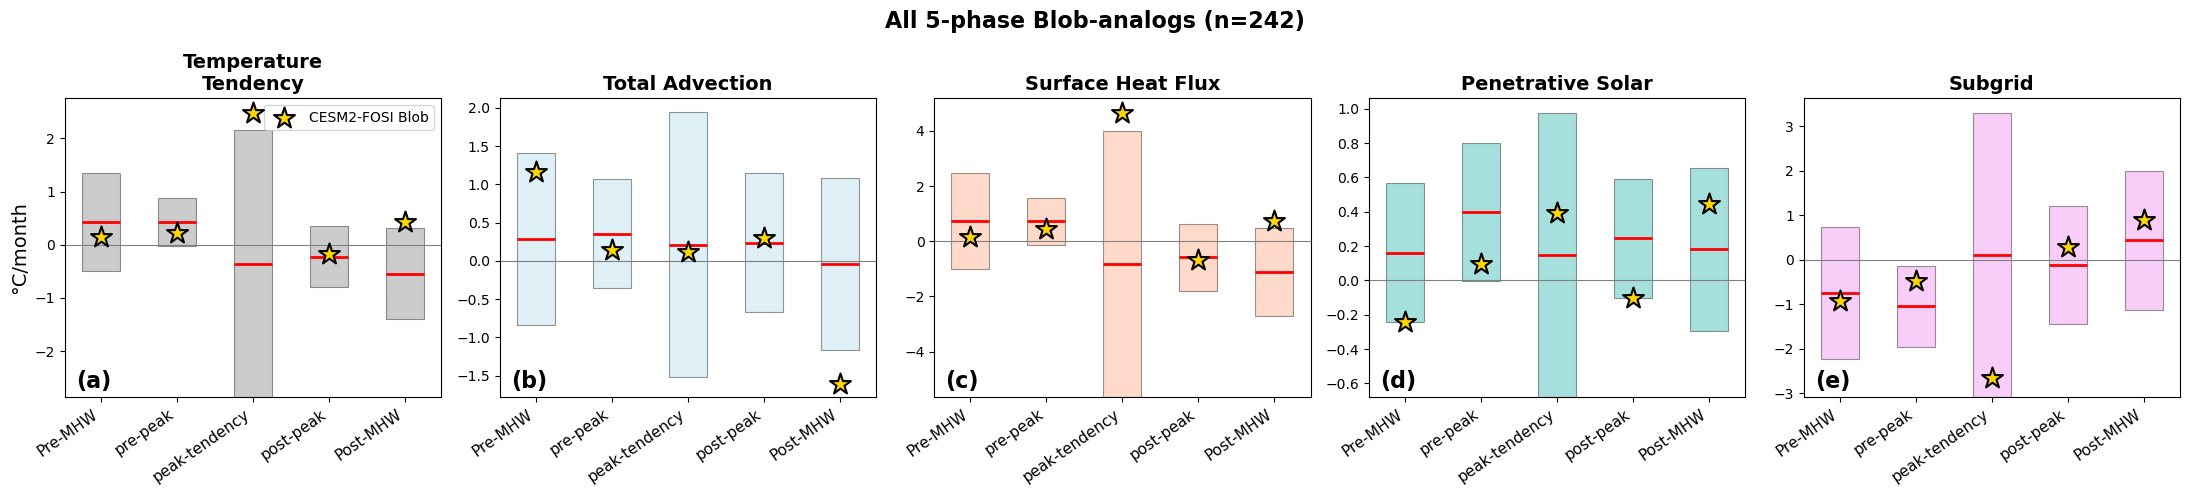

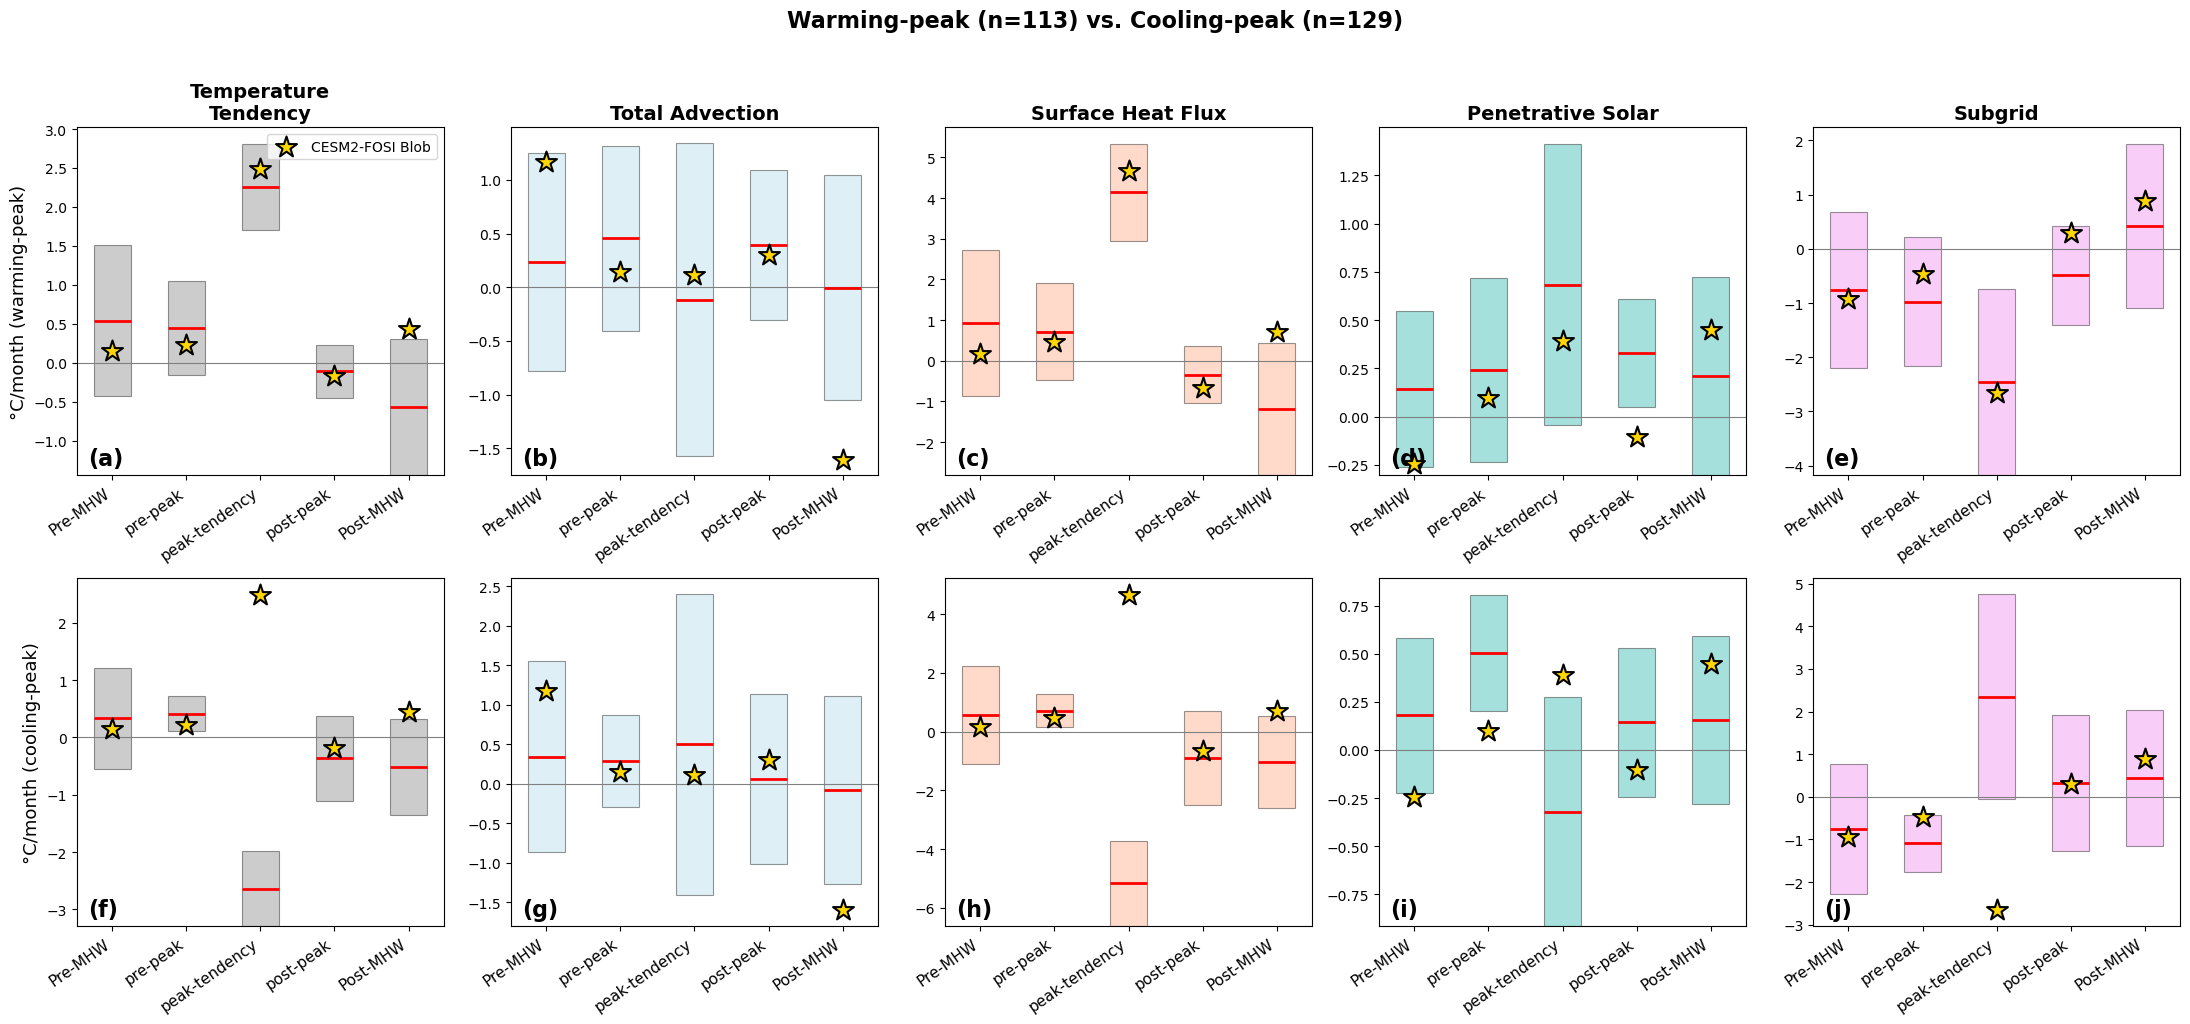

In [8]:
# ============================================================
# Adaptive phase-splitting: peak-tendency month = max |TEND_TEMP| within core
# (NOT max SSTa -- this is the definitional point Anna/Liz flagged; see Methods)
# ============================================================
def phase_split_adaptive(term_profiles, pre_post_months=2, min_months_for_5phase=8):
    """
    Splits an event's heat budget profile into either:
      - 3 phases (Pre-MHW, detection, Post-MHW) if core duration < min_months_for_5phase
      - 5 phases (Pre-MHW, pre-peak, peak-tendency, post-peak, Post-MHW) otherwise

    peak-tendency month = the month of maximum ABSOLUTE TEND_TEMP within the core
    detection window, i.e. maximum rate of change regardless of sign. This can be
    a positive tendency (warming-peak) or negative tendency (cooling-peak) -- it is
    NOT the month of maximum SSTa. See Methods 2.3.2 for full justification.
    """
    tend_temp = term_profiles['TEND_TEMP']
    n_total = len(tend_temp.time)
    core_start = pre_post_months
    core_end = n_total - pre_post_months
    core_length = core_end - core_start

    if core_length < min_months_for_5phase:
        result = {}
        for term, ts in term_profiles.items():
            result[term] = {
                'Pre-MHW':  float(ts.isel(time=slice(0, core_start)).mean()),
                'detection': float(ts.isel(time=slice(core_start, core_end)).mean()),
                'Post-MHW': float(ts.isel(time=slice(-pre_post_months, None)).mean()),
            }
        return result, 3, None

    core_tend = tend_temp.isel(time=slice(core_start, core_end))
    peak_idx_within_core = int(np.abs(core_tend.values).argmax())
    peak_idx_global = core_start + peak_idx_within_core
    has_prepeak = peak_idx_global > core_start
    has_postpeak = peak_idx_global < core_end - 1

    result = {}
    for term, ts in term_profiles.items():
        result[term] = {
            'Pre-MHW':  float(ts.isel(time=slice(0, core_start)).mean()),
            'pre-peak': float(ts.isel(time=slice(core_start, peak_idx_global)).mean()) if has_prepeak else np.nan,
            'peak-tendency': float(ts.isel(time=peak_idx_global)),
            'post-peak': float(ts.isel(time=slice(peak_idx_global + 1, core_end)).mean()) if has_postpeak else np.nan,
            'Post-MHW': float(ts.isel(time=slice(-pre_post_months, None)).mean()),
        }
    peak_date = tend_temp.time.values[peak_idx_global]
    return result, 5, peak_date


PHASE_NAMES_3 = ['Pre-MHW', 'detection', 'Post-MHW']
PHASE_NAMES_5 = ['Pre-MHW', 'pre-peak', 'peak-tendency', 'post-peak', 'Post-MHW']
TERMS = ['TEND_TEMP', 'TOT_ADV', 'SHF_depth', 'QSW_3D', 'SUBGRID']


# ============================================================
# Run + verify FOSI Blob (should be 5-phase, peak = Jan 2015 per manuscript)
# ============================================================
fosi_phases_5, fosi_n_phases, fosi_peak_date = phase_split_adaptive(fosi_hb_profile)
print(f"FOSI Blob: {fosi_n_phases}-phase, peak-tendency month = {str(fosi_peak_date)[:7]}")
print(f"VERIFY: should be 5-phase, peak = 2015-01 (per manuscript: peak tendency 2.5°C/month)")
print(f"FOSI peak-tendency TEND_TEMP = {fosi_phases_5['TEND_TEMP']['peak-tendency']:.2f} °C/month -- VERIFY: ~2.5")
print(f"FOSI peak-tendency SHF_depth = {fosi_phases_5['SHF_depth']['peak-tendency']:.2f} °C/month -- VERIFY: ~4.7")

fosi_phases_3, _, _ = phase_split_adaptive(fosi_hb_profile, min_months_for_5phase=999)  # force 3-phase for comparison


# ============================================================
# LENS: per-member heat budget processing (crash-safe, resumable)
# ============================================================
def load_lens_heat_budget_full(member_id):
    ds_terms = xr.open_dataset(
        f'/glade/derecho/scratch/cmendiola/heat_budget_blob_fosi_lens2_paper/heat_budget_{member_id}_03172026.nc'
    )
    ds_tend = xr.open_dataset(
        f'/glade/derecho/scratch/cmendiola/heat_budget_blob_fosi_lens2_paper/heat_budget_onlytemptend_{member_id}_07242026.nc'
    )
    return xr.merge([ds_terms, ds_tend])


def process_one_member_heat_budget(member_id, labels_full, analog_ids_for_member, NEPac_mask):
    if not analog_ids_for_member:
        return {}
    hb_raw = load_lens_heat_budget_full(member_id)
    hb_raw['SUBGRID'] = hb_raw['TEND_TEMP'] - (hb_raw['TOT_ADV'] + hb_raw['SHF_depth'] + hb_raw['QSW_3D'])

    hb_detrended = {term: detrend_term(hb_raw[term]) for term in TERMS}
    hb_cropped = {term: da.isel(nlat_t=lat_slice, nlon_t=lon_slice) for term, da in hb_detrended.items()}
    hb_masked = {term: da.where(NEPac_mask == 1) for term, da in hb_cropped.items()}

    member_labels = labels_full.isel(ensemble_member=member_id)
    member_profiles = {}
    for analog_id in analog_ids_for_member:
        key = (member_id, analog_id)
        mask = (member_labels == analog_id)
        times_present = member_labels.time.where(mask.any(dim=('lat', 'lon')), drop=True)
        if len(times_present) == 0:
            continue
        padded_times = build_padded_time_window(member_labels.time, times_present)
        term_profiles = {
            term: da.sel(time=padded_times).mean(dim=('nlat_t', 'nlon_t')).compute()
            for term, da in hb_masked.items()
        }
        member_profiles[key] = {
            'terms': term_profiles,
            'season': pd.Timestamp(str(times_present.values[0])).month,
        }
    print(f"Member {member_id} done")
    return member_profiles


# output_dir_hb = '/glade/derecho/scratch/cassiacai/heat_budget_profiles_by_member'
# os.makedirs(output_dir_hb, exist_ok=True)
labels_full = da_mhwobj_labels_by_method['linear']

# t0 = time.time()
# for member_id in range(100):
#     save_path = f'{output_dir_hb}/member_{member_id}.pkl'
#     if os.path.exists(save_path):
#         print(f"Member {member_id} already done, skipping")
#         continue
#     member_profiles = process_one_member_heat_budget(
#         member_id, labels_full, blob_analog_ids['linear'][member_id], NEPac_MHW_renamed_latlon
#     )
#     with open(save_path, 'wb') as f:
#         pickle.dump(member_profiles, f)
#     print(f"Member {member_id} done ({time.time()-t0:.1f}s elapsed)")

output_dir_hb = '/glade/derecho/scratch/cassiacai/heat_budget_profiles_by_member'

# ============================================================
# Reload all member results, apply adaptive phase-splitting
# ============================================================
heat_budget_profiles_all = {}
for member_id in range(100):
    save_path = f'{output_dir_hb}/member_{member_id}.pkl'
    if os.path.exists(save_path):
        with open(save_path, 'rb') as f:
            heat_budget_profiles_all.update(pickle.load(f))
print(f"Total analogs loaded: {len(heat_budget_profiles_all)} -- VERIFY: should be 331")

hb_phases_all = {}
phase_count_used = {3: 0, 5: 0}
for key, data in heat_budget_profiles_all.items():
    phases, n_phases, peak_date = phase_split_adaptive(data['terms'])
    hb_phases_all[key] = {'phases': phases, 'n_phases': n_phases, 'peak_date': peak_date}
    phase_count_used[n_phases] += 1

print(f"3-phase: {phase_count_used[3]}, 5-phase: {phase_count_used[5]}")
print("VERIFY: should be 89 three-phase, 242 five-phase (331 total)")


# ============================================================
# Warming-peak vs. cooling-peak split (sign of TEND_TEMP at peak-tendency month)
# ============================================================
keys_5phase = [k for k, v in hb_phases_all.items() if v['n_phases'] == 5]

def separate_peak_by_sign(keys, hb_phases_all):
    warming_keys, cooling_keys = [], []
    for key in keys:
        tend_peak = hb_phases_all[key]['phases']['TEND_TEMP']['peak-tendency']
        if np.isnan(tend_peak):
            continue
        (warming_keys if tend_peak > 0 else cooling_keys).append(key)
    return warming_keys, cooling_keys

warming_keys, cooling_keys = separate_peak_by_sign(keys_5phase, hb_phases_all)
print(f"Warming-peak: {len(warming_keys)}, Cooling-peak: {len(cooling_keys)}")
print("VERIFY: should be n=113 warming-peak, n=129 cooling-peak")


# ============================================================
# Composite (mean, std, n) per term/phase, for an arbitrary key subset
# ============================================================
def composite_phase_group(keys, hb_phases_all, phase_names):
    composite = {term: {p: [] for p in phase_names} for term in TERMS}
    for key in keys:
        phases = hb_phases_all[key]['phases']
        for term in composite:
            for p in phase_names:
                val = phases[term].get(p, np.nan)
                if not np.isnan(val):
                    composite[term][p].append(val)
    result = {}
    for term, phase_dict in composite.items():
        result[term] = {}
        for p, vals in phase_dict.items():
            arr = np.array(vals)
            mean = np.nanmean(arr) if len(arr) > 0 else np.nan
            std = np.nanstd(arr) if len(arr) > 0 else np.nan
            result[term][p] = (mean, std, len(arr))
    return result


def get_individual_values_by_phase(keys, hb_phases_all, term, phase_names):
    result = {p: [] for p in phase_names}
    for key in keys:
        phases = hb_phases_all[key]['phases']
        for p in phase_names:
            val = phases[term].get(p, np.nan)
            if not np.isnan(val):
                result[p].append(val)
    return result


# ============================================================
# ADDRESSING ANNA'S QUESTION: composite using ALL 5-phase analogs
# vs. warming-only / cooling-only, side by side
# ============================================================
composite_all_5phase = composite_phase_group(keys_5phase, hb_phases_all, PHASE_NAMES_5)
composite_warming = composite_phase_group(warming_keys, hb_phases_all, PHASE_NAMES_5)
composite_cooling = composite_phase_group(cooling_keys, hb_phases_all, PHASE_NAMES_5)

print("\n=== Comparison at peak-tendency month: ALL vs. warming-only vs. cooling-only ===")
for term in TERMS:
    all_mean, all_std, all_n = composite_all_5phase[term]['peak-tendency']
    warm_mean, warm_std, warm_n = composite_warming[term]['peak-tendency']
    cool_mean, cool_std, cool_n = composite_cooling[term]['peak-tendency']
    print(f"{term}: ALL(n={all_n})={all_mean:.2f}±{all_std:.2f} | "
          f"warming(n={warm_n})={warm_mean:.2f}±{warm_std:.2f} | "
          f"cooling(n={cool_n})={cool_mean:.2f}±{cool_std:.2f}")


# ============================================================
# Budget closure check: TEND_TEMP should ≈ sum(TOT_ADV, SHF_depth, QSW_3D, SUBGRID)
# (True by construction here since SUBGRID is defined as the residual -- this
# checks internal consistency of the pipeline, not an independent verification)
# ============================================================
print("\n=== Budget closure check (all 5-phase analogs) ===")
for phase in PHASE_NAMES_5:
    tend_mean = composite_all_5phase['TEND_TEMP'][phase][0]
    sum_terms = sum(composite_all_5phase[t][phase][0] for t in ['TOT_ADV', 'SHF_depth', 'QSW_3D', 'SUBGRID'])
    print(f"{phase}: TEND_TEMP={tend_mean:.3f}, sum of terms={sum_terms:.3f}, diff={tend_mean-sum_terms:.3f}")
print("NOTE: closure here is definitional (SUBGRID = TEND_TEMP - sum of others), "
      "not an independent check. See manuscript: 'CESM2's heat budget closes bit-for-bit "
      "when all subgrid-scale diagnostics are available' -- confirm whether FOSI's actual "
      "(non-residual) subgrid terms are available and worth cross-checking against this.")


# ============================================================
# Percentile / return period: FOSI Blob vs. warming-peak analogs, per term/phase
# ============================================================
N_years = 100 * 42

def get_percentile_and_rp(term, phase, keys, hb_phases_all, blob_val):
    values = np.array(get_individual_values_by_phase(keys, hb_phases_all, term, [phase])[phase])
    if len(values) == 0 or np.isnan(blob_val):
        return None, None, None
    p = np.mean(values >= blob_val)
    rp = N_years / (len(values) * p) if p > 0 else np.inf
    return 100 * (1 - p), p, rp

blob_values_by_term_5 = {
    term: {p: fosi_phases_5[term].get(p, np.nan) for p in PHASE_NAMES_5}
    for term in TERMS
}

print("\n=== FOSI Blob percentile vs. warming-peak analogs (n={}) ===".format(len(warming_keys)))
for term in TERMS:
    for phase in PHASE_NAMES_5:
        blob_val = blob_values_by_term_5[term].get(phase, np.nan)
        pct, p_exceed, rp = get_percentile_and_rp(term, phase, warming_keys, hb_phases_all, blob_val)
        if pct is not None:
            print(f"{term} - {phase}: Blob={blob_val:.2f}, percentile={pct:.1f}, "
                  f"{100*p_exceed:.1f}% exceed, RP={rp:.1f} yr")


# ============================================================
# Plotting: one function, blob marked with gold star, used for any group
# ============================================================
def plot_term_panel_with_blob(ax, term, phase_names, composite, blob_values, title, color):
    x = np.arange(len(phase_names))
    for i, phase in enumerate(phase_names):
        mean, std, n = composite[term][phase]
        ax.bar(i, 2*std, bottom=mean-std, width=0.5, color=color, alpha=0.4, edgecolor='k', linewidth=0.8)
        ax.hlines(mean, i-0.25, i+0.25, color='red', linewidth=2, zorder=5)
        if phase in blob_values and not np.isnan(blob_values[phase]):
            ax.scatter(i, blob_values[phase], color='gold', edgecolor='black', s=250,
                       marker='*', zorder=20, linewidth=1.5, label='CESM2-FOSI Blob' if i == 0 else None)
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(phase_names, fontsize=11, rotation=35, ha='right')
    ax.set_title(title, fontsize=14, fontweight='bold')


term_titles = {
    'TEND_TEMP': 'Temperature\nTendency', 'TOT_ADV': 'Total Advection',
    'SHF_depth': 'Surface Heat Flux', 'QSW_3D': 'Penetrative Solar', 'SUBGRID': 'Subgrid',
}
term_colors = {
    'TEND_TEMP': 'gray', 'TOT_ADV': 'lightblue',
    'SHF_depth': 'lightsalmon', 'QSW_3D': 'lightseagreen', 'SUBGRID': 'violet',
}
panel_letters = ['(a)', '(b)', '(c)', '(d)', '(e)']

# --- Figure: ALL 5-phase analogs (addresses Anna's "have you tested with all analogs" directly) ---
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, term, letter in zip(axes, TERMS, panel_letters):
    plot_term_panel_with_blob(ax, term, PHASE_NAMES_5, composite_all_5phase,
                               blob_values_by_term_5[term], term_titles[term], term_colors[term])
    ax.text(0.03, 0.03, letter, transform=ax.transAxes, fontsize=16, fontweight='bold')
    if ax == axes[0]:
        ax.set_ylabel('°C/month', fontsize=14)
        ax.legend(fontsize=10, loc='upper right')
fig.suptitle(f'All 5-phase Blob-analogs (n={len(keys_5phase)})', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('Figure_heat_budget_all_analogs_5panel.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Figure: Warming-peak vs. cooling-peak, side by side (2 rows) ---
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
for ax, term, letter in zip(axes[0], TERMS, panel_letters):
    plot_term_panel_with_blob(ax, term, PHASE_NAMES_5, composite_warming,
                               blob_values_by_term_5[term], term_titles[term], term_colors[term])
    ax.text(0.03, 0.03, letter, transform=ax.transAxes, fontsize=16, fontweight='bold')
    if ax == axes[0, 0]:
        ax.set_ylabel('°C/month (warming-peak)', fontsize=13)
        ax.legend(fontsize=10, loc='upper right')

letters_row2 = ['(f)', '(g)', '(h)', '(i)', '(j)']
for ax, term, letter in zip(axes[1], TERMS, letters_row2):
    plot_term_panel_with_blob(ax, term, PHASE_NAMES_5, composite_cooling,
                               blob_values_by_term_5[term], '', term_colors[term])
    ax.text(0.03, 0.03, letter, transform=ax.transAxes, fontsize=16, fontweight='bold')
    if ax == axes[1, 0]:
        ax.set_ylabel('°C/month (cooling-peak)', fontsize=13)

fig.suptitle(f'Warming-peak (n={len(warming_keys)}) vs. Cooling-peak (n={len(cooling_keys)})',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Figure_heat_budget_warming_vs_cooling_5panel.png', dpi=300, bbox_inches='tight')
plt.show()

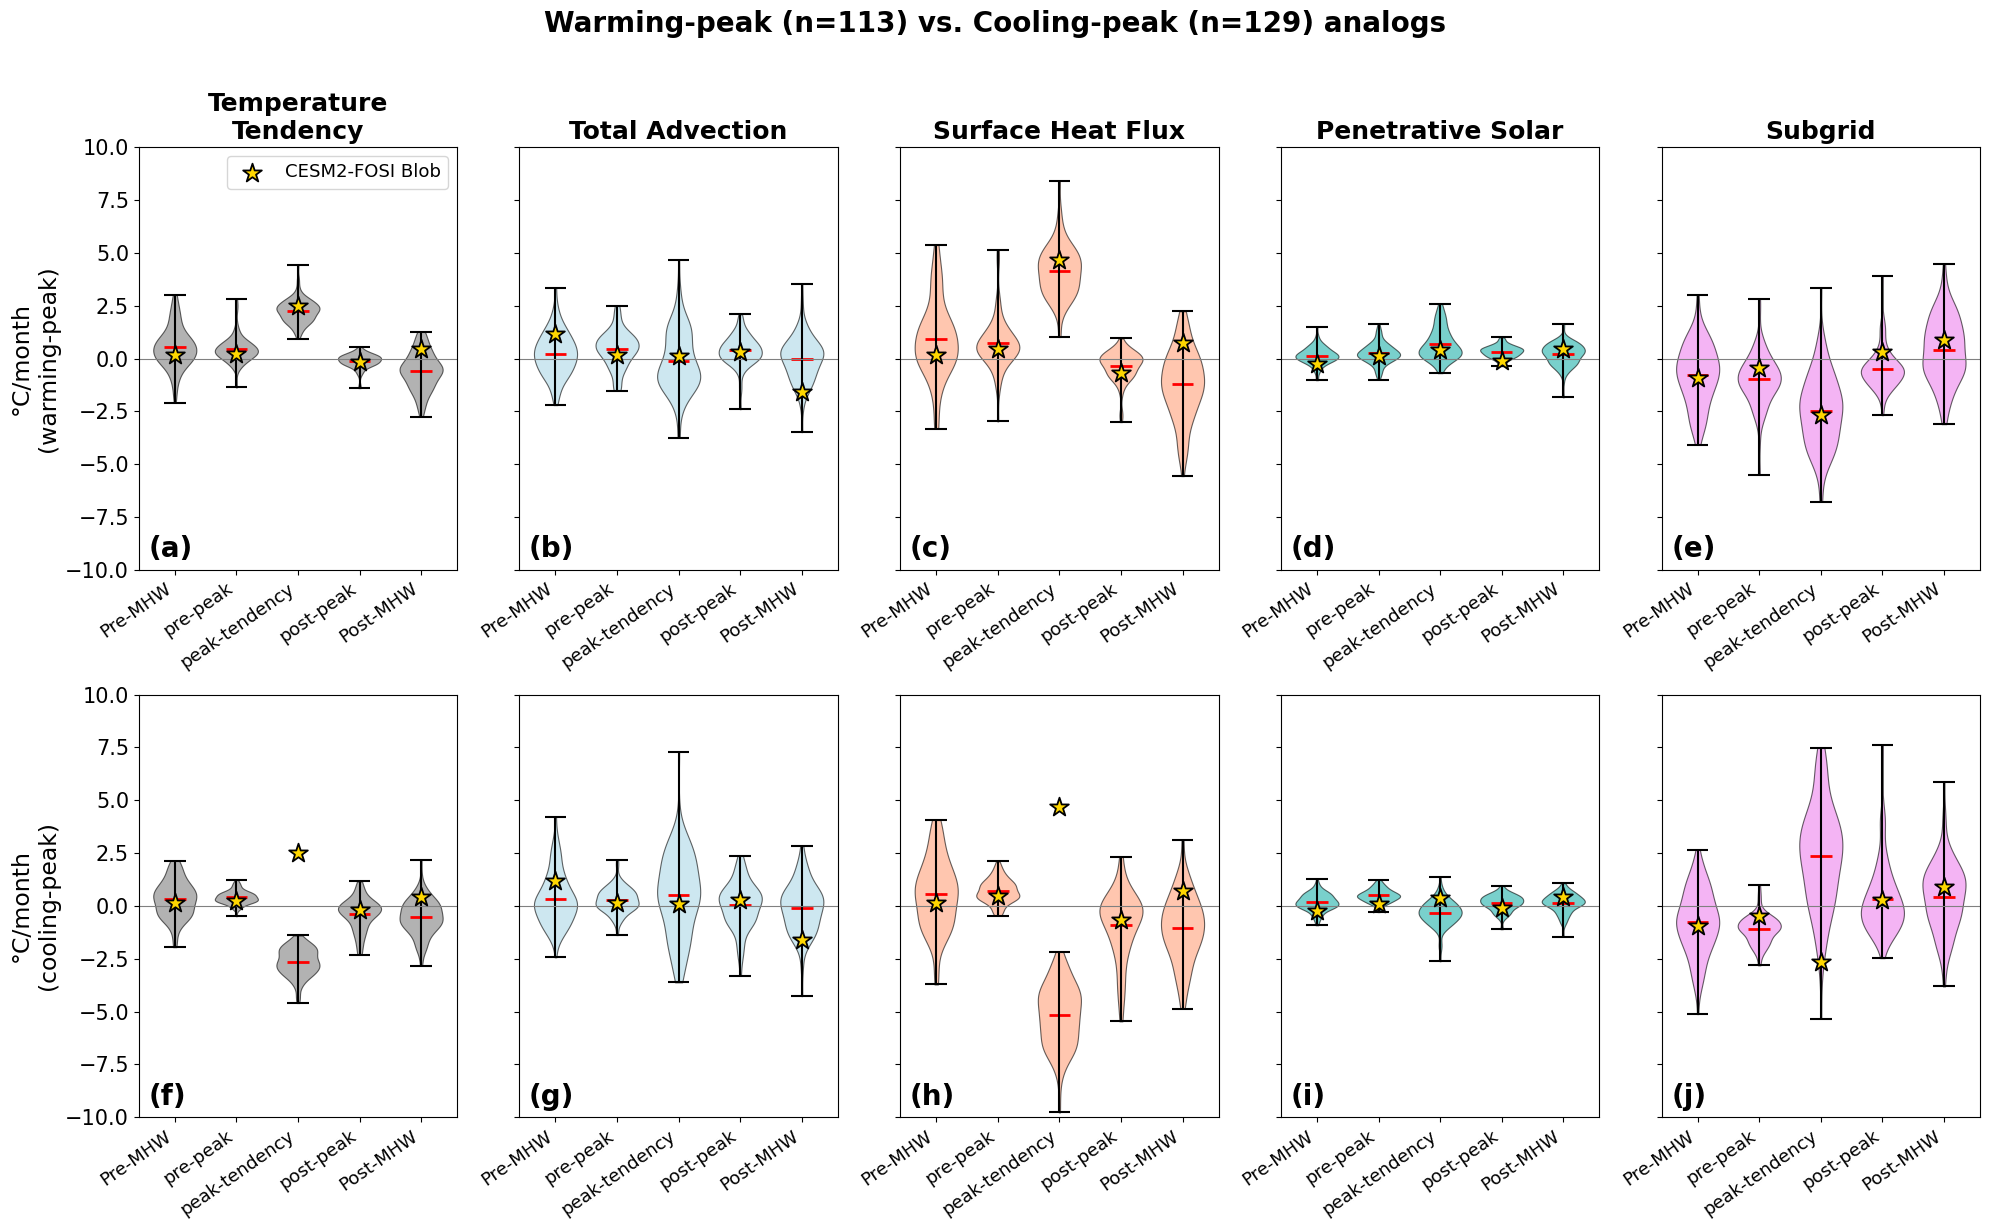

In [15]:
def plot_term_panel_violin_group(ax, term, phase_names, keys, hb_phases_all, blob_values, title, color):
    individual_vals = get_individual_values_by_phase(keys, hb_phases_all, term, phase_names)
    data_for_violin = [individual_vals[p] for p in phase_names]
    positions = np.arange(len(phase_names))

    parts = ax.violinplot(data_for_violin, positions=positions, showmeans=True, showmedians=False, widths=0.7)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.6)
        pc.set_edgecolor('k')
        pc.set_linewidth(0.8)
    parts['cmeans'].set_color('red')
    parts['cmeans'].set_linewidth(2)
    parts['cbars'].set_color('k')
    parts['cmins'].set_color('k')
    parts['cmaxes'].set_color('k')

    for i, phase in enumerate(phase_names):
        if phase in blob_values and not np.isnan(blob_values[phase]):
            ax.scatter(i, blob_values[phase], color='gold', edgecolor='black', s=200,
                       marker='*', zorder=20, linewidth=1.3, label='CESM2-FOSI Blob' if i == 0 else None)

    ax.axhline(0, color='gray', linewidth=0.8)
    ax.set_xticks(positions)
    ax.set_xticklabels(phase_names, fontsize=13, rotation=35, ha='right')
    ax.set_title(title, fontsize=18, fontweight='bold')


# ============================================================
# Warming-peak vs. cooling-peak violin plot, all terms, shared y-axis
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(20, 12))

for ax, term, letter in zip(axes[0], TERMS, panel_letters):
    plot_term_panel_violin_group(ax, term, PHASE_NAMES_5, warming_keys, hb_phases_all,
                                  blob_values_by_term_5[term], term_titles[term], term_colors[term])
    ax.text(0.03, 0.03, letter, transform=ax.transAxes, fontsize=20, fontweight='bold')
    ax.tick_params(axis='y', labelsize=15)
    ax.set_ylim(-10, 10)
    if ax == axes[0, 0]:
        ax.set_ylabel('°C/month\n(warming-peak)', fontsize=17)
        ax.legend(fontsize=13, loc='upper right', frameon=True)
    else:
        ax.set_yticklabels([])

letters_row2 = ['(f)', '(g)', '(h)', '(i)', '(j)']
for ax, term, letter in zip(axes[1], TERMS, letters_row2):
    plot_term_panel_violin_group(ax, term, PHASE_NAMES_5, cooling_keys, hb_phases_all,
                                  blob_values_by_term_5[term], '', term_colors[term])
    ax.text(0.03, 0.03, letter, transform=ax.transAxes, fontsize=20, fontweight='bold')
    ax.tick_params(axis='y', labelsize=15)
    ax.set_ylim(-10, 10)
    if ax == axes[1, 0]:
        ax.set_ylabel('°C/month\n(cooling-peak)', fontsize=17)
    else:
        ax.set_yticklabels([])

fig.suptitle(f'Warming-peak (n={len(warming_keys)}) vs. Cooling-peak (n={len(cooling_keys)}) analogs',
             fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Figure_heat_budget_warming_vs_cooling_violin.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
import json

# ============================================================
# Load the non-canonical (full-lifetime footprint) analog IDs,
# already computed during the PDO/ENSO sensitivity check
# ============================================================
with open('/glade/derecho/scratch/cassiacai/noncanonical_matched_analogs.json', 'r') as f:
    noncanonical_matched_raw = json.load(f)

# Convert from {method: {member_id_str: [ids]}} back to list-of-lists-per-member,
# matching the structure blob_analog_ids['linear'] already uses
blob_analog_ids_noncanonical = {}
for method, members_dict in noncanonical_matched_raw.items():
    n_members = len(da_mhwobj_labels_by_method[method].ensemble_member)
    method_list = [[] for _ in range(n_members)]
    for member_id_str, ids in members_dict.items():
        method_list[int(member_id_str)] = ids
    blob_analog_ids_noncanonical[method] = method_list

n_noncanon_linear = sum(len(v) for v in blob_analog_ids_noncanonical['linear'])
print(f"Non-canonical (full-footprint) linear analog count: {n_noncanon_linear}")
print("VERIFY: should match 118 from the earlier PDO/ENSO sensitivity check")


# ============================================================
# Rerun heat budget processing using the non-canonical population
# (spatial averaging still uses the canonical NEPac_mask -- only the
# SELECTION criterion changes here, not the averaging region)
# ============================================================
output_dir_hb_noncanonical = '/glade/derecho/scratch/cassiacai/heat_budget_profiles_by_member_noncanonical'
# os.makedirs(output_dir_hb_noncanonical, exist_ok=True)

# t0 = time.time()
# for member_id in range(100):
#     save_path = f'{output_dir_hb_noncanonical}/member_{member_id}.pkl'
#     if os.path.exists(save_path):
#         print(f"Member {member_id} already done, skipping")
#         continue
#     member_profiles = process_one_member_heat_budget(
#         member_id, labels_full, blob_analog_ids_noncanonical['linear'][member_id], NEPac_MHW_renamed_latlon
#     )
#     with open(save_path, 'wb') as f:
#         pickle.dump(member_profiles, f)
#     print(f"Member {member_id} done ({time.time()-t0:.1f}s elapsed)")


# ============================================================
# Reload, phase-split, composite -- same pipeline as canonical
# ============================================================
heat_budget_profiles_noncanonical = {}
for member_id in range(100):
    save_path = f'{output_dir_hb_noncanonical}/member_{member_id}.pkl'
    if os.path.exists(save_path):
        with open(save_path, 'rb') as f:
            heat_budget_profiles_noncanonical.update(pickle.load(f))
print(f"Total non-canonical analogs loaded: {len(heat_budget_profiles_noncanonical)}")

hb_phases_noncanonical = {}
for key, data in heat_budget_profiles_noncanonical.items():
    phases, n_phases, peak_date = phase_split_adaptive(data['terms'])
    hb_phases_noncanonical[key] = {'phases': phases, 'n_phases': n_phases, 'peak_date': peak_date}

keys_5phase_noncanonical = [k for k, v in hb_phases_noncanonical.items() if v['n_phases'] == 5]
warming_keys_noncanonical, cooling_keys_noncanonical = separate_peak_by_sign(keys_5phase_noncanonical, hb_phases_noncanonical)
print(f"Non-canonical: {len(warming_keys_noncanonical)} warming-peak, {len(cooling_keys_noncanonical)} cooling-peak")

composite_noncanonical_all = composite_phase_group(keys_5phase_noncanonical, hb_phases_noncanonical, PHASE_NAMES_5)

# ============================================================
# Compare peak-tendency composites: canonical selection vs. non-canonical selection
# ============================================================
print("\n=== Peak-tendency: canonical selection vs. non-canonical (full-footprint) selection ===")
for term in TERMS:
    canon_mean, canon_std, canon_n = composite_all_5phase[term]['peak-tendency']
    noncanon_mean, noncanon_std, noncanon_n = composite_noncanonical_all[term]['peak-tendency']
    print(f"{term}: canonical(n={canon_n})={canon_mean:.2f}±{canon_std:.2f} | "
          f"non-canonical(n={noncanon_n})={noncanon_mean:.2f}±{noncanon_std:.2f}")

Non-canonical (full-footprint) linear analog count: 118
VERIFY: should match 118 from the earlier PDO/ENSO sensitivity check
Total non-canonical analogs loaded: 118
Non-canonical: 44 warming-peak, 67 cooling-peak

=== Peak-tendency: canonical selection vs. non-canonical (full-footprint) selection ===
TEND_TEMP: canonical(n=242)=-0.35±2.52 | non-canonical(n=111)=-0.65±2.65
TOT_ADV: canonical(n=242)=0.21±1.74 | non-canonical(n=111)=0.28±1.79
SHF_depth: canonical(n=242)=-0.82±4.83 | non-canonical(n=111)=-1.42±5.11
QSW_3D: canonical(n=242)=0.15±0.83 | non-canonical(n=111)=0.02±0.66
SUBGRID: canonical(n=242)=0.11±3.20 | non-canonical(n=111)=0.47±3.15


In [17]:
# ============================================================
# Assuming Part 1 (non-canonical SELECTION, canonical spatial averaging) already ran
# and heat_budget_profiles_noncanonical / hb_phases_noncanonical / composite_noncanonical_all exist
# ============================================================
print("=== Part 1: Selection-only sensitivity (canonical vs non-canonical population) ===")
print(f"Canonical: n={len(keys_5phase)} five-phase analogs")
print(f"Non-canonical (full-footprint selection): n={len(keys_5phase_noncanonical)} five-phase analogs")

for term in TERMS:
    canon_mean, canon_std, canon_n = composite_all_5phase[term]['peak-tendency']
    noncanon_mean, noncanon_std, noncanon_n = composite_noncanonical_all[term]['peak-tendency']
    print(f"{term} @ peak-tendency: canonical={canon_mean:.2f}\u00b1{canon_std:.2f} (n={canon_n}) | "
          f"non-canonical selection={noncanon_mean:.2f}\u00b1{noncanon_std:.2f} (n={noncanon_n})")

=== Part 1: Selection-only sensitivity (canonical vs non-canonical population) ===
Canonical: n=242 five-phase analogs
Non-canonical (full-footprint selection): n=111 five-phase analogs
TEND_TEMP @ peak-tendency: canonical=-0.35±2.52 (n=242) | non-canonical selection=-0.65±2.65 (n=111)
TOT_ADV @ peak-tendency: canonical=0.21±1.74 (n=242) | non-canonical selection=0.28±1.79 (n=111)
SHF_depth @ peak-tendency: canonical=-0.82±4.83 (n=242) | non-canonical selection=-1.42±5.11 (n=111)
QSW_3D @ peak-tendency: canonical=0.15±0.83 (n=242) | non-canonical selection=0.02±0.66 (n=111)
SUBGRID @ peak-tendency: canonical=0.11±3.20 (n=242) | non-canonical selection=0.47±3.15 (n=111)


In [18]:
pop_grid_ref = xr.open_dataset('/glade/derecho/scratch/cassiacai/mean_image_3_POP.nc')
print("Coords:", list(pop_grid_ref.coords))
print("Data vars:", list(pop_grid_ref.data_vars))

Coords: ['ULONG', 'ULAT', 'TLONG', 'TLAT']
Data vars: ['__xarray_dataarray_variable__']


In [19]:
# ============================================================
# FIX: crop the POP grid reference to match hb_cropped's exact tile
# BEFORE building the regridder, so output dimensions align
# ============================================================
def build_labels_to_pop_regridder(labels_grid_da, pop_target_grid_ds_cropped, method='nearest_s2d'):
    """
    pop_target_grid_ds_cropped: the POP grid reference, ALREADY cropped with the
    same nlat/nlon slices used for the heat budget data, so the regridder's
    output grid matches hb_cropped's dimensions exactly.
    """
    ds_in = xr.Dataset(
        coords={'lat': labels_grid_da.lat.values, 'lon': labels_grid_da.lon.values}
    )
    ds_out = xr.Dataset(
        coords={
            'lat': (('nlat_t', 'nlon_t'), pop_target_grid_ds_cropped.TLAT.values),
            'lon': (('nlat_t', 'nlon_t'), pop_target_grid_ds_cropped.TLONG.values),
        }
    )
    regridder = xe.Regridder(ds_in, ds_out, method, periodic=True)
    return regridder


# ============================================================
# Crop pop_grid_ref with the SAME lat_slice/lon_slice as everything else,
# then rename dims to match nlat_t/nlon_t
# ============================================================
pop_grid_ref_cropped = pop_grid_ref.isel(nlat=lat_slice, nlon=lon_slice).rename({'nlat': 'nlat_t', 'nlon': 'nlon_t'})

print("Cropped POP grid shape check:", pop_grid_ref_cropped.TLAT.shape)
print("Expect this to match hb_cropped's (nlat_t, nlon_t) shape, e.g. (163, ...)")


# ============================================================
# Rebuild the regridder using the CROPPED grid reference
# ============================================================
regridder = build_labels_to_pop_regridder(
    labels_full.isel(ensemble_member=TEST_MEMBER_ID, time=0),
    pop_grid_ref_cropped
)

t0 = time.time()
test_profiles = process_one_member_heat_budget_timevarying(
    TEST_MEMBER_ID, labels_full, blob_analog_ids['linear'][TEST_MEMBER_ID], regridder
)
print(f"Member {TEST_MEMBER_ID} time-varying: {len(test_profiles)} analogs, {time.time()-t0:.1f}s")

sample_key = list(test_profiles.keys())[0]
print("Time-varying TEND_TEMP:", test_profiles[sample_key]['terms']['TEND_TEMP'].values)
if sample_key in heat_budget_profiles_all:
    print("Canonical TEND_TEMP:  ", heat_budget_profiles_all[sample_key]['terms']['TEND_TEMP'].values)

Cropped POP grid shape check: (163, 90)
Expect this to match hb_cropped's (nlat_t, nlon_t) shape, e.g. (163, ...)


NameError: name 'TEST_MEMBER_ID' is not defined

In [16]:
# output_dir_hb_timevarying = '/glade/derecho/scratch/cassiacai/heat_budget_profiles_by_member_timevarying'
# os.makedirs(output_dir_hb_timevarying, exist_ok=True)

# t0 = time.time()
# for member_id in range(100):
#     save_path = f'{output_dir_hb_timevarying}/member_{member_id}.pkl'
#     if os.path.exists(save_path):
#         print(f"Member {member_id} already done, skipping")
#         continue
#     member_profiles = process_one_member_heat_budget_timevarying(
#         member_id, labels_full, blob_analog_ids['linear'][member_id], regridder
#     )
#     with open(save_path, 'wb') as f:
#         pickle.dump(member_profiles, f)
#     print(f"Member {member_id} done ({time.time()-t0:.1f}s elapsed)")

# print(f"Total time: {time.time()-t0:.1f}s")

Member 0 done (time-varying)
Member 0 done (5.3s elapsed)
Member 1 done (time-varying)
Member 1 done (12.4s elapsed)
Member 2 done (time-varying)
Member 2 done (19.6s elapsed)
Member 3 done (time-varying)
Member 3 done (26.8s elapsed)
Member 4 done (time-varying)
Member 4 done (34.0s elapsed)
Member 5 done (time-varying)
Member 5 done (41.2s elapsed)
Member 6 done (time-varying)
Member 6 done (48.6s elapsed)
Member 7 done (time-varying)
Member 7 done (55.9s elapsed)
Member 8 done (time-varying)
Member 8 done (62.9s elapsed)
Member 9 done (time-varying)
Member 9 done (69.9s elapsed)
Member 10 done (time-varying)
Member 10 done (77.0s elapsed)
Member 11 done (time-varying)
Member 11 done (84.0s elapsed)
Member 12 done (time-varying)
Member 12 done (91.2s elapsed)
Member 13 done (time-varying)
Member 13 done (98.3s elapsed)
Member 14 done (time-varying)
Member 14 done (105.8s elapsed)
Member 15 done (time-varying)
Member 15 done (112.8s elapsed)
Member 16 done (time-varying)
Member 16 don

In [18]:
output_dir_hb_timevarying = '/glade/derecho/scratch/cassiacai/heat_budget_profiles_by_member_timevarying'

heat_budget_profiles_timevarying = {}
for member_id in range(100):
    save_path = f'{output_dir_hb_timevarying}/member_{member_id}.pkl'
    if os.path.exists(save_path):
        with open(save_path, 'rb') as f:
            heat_budget_profiles_timevarying.update(pickle.load(f))
print(f"Total time-varying analogs loaded: {len(heat_budget_profiles_timevarying)}")
print("VERIFY: should be 331, same as canonical (this only changes averaging region, not selection)")

hb_phases_timevarying = {}
for key, data in heat_budget_profiles_timevarying.items():
    phases, n_phases, peak_date = phase_split_adaptive(data['terms'])
    hb_phases_timevarying[key] = {'phases': phases, 'n_phases': n_phases, 'peak_date': peak_date}

keys_5phase_timevarying = [k for k, v in hb_phases_timevarying.items() if v['n_phases'] == 5]
print(f"5-phase: {len(keys_5phase_timevarying)}")

composite_timevarying_all = composite_phase_group(keys_5phase_timevarying, hb_phases_timevarying, PHASE_NAMES_5)

print("\n=== Peak-tendency: canonical spatial averaging vs. time-varying spatial averaging ===")
for term in TERMS:
    c_mean, c_std, c_n = composite_all_5phase[term]['peak-tendency']
    t_mean, t_std, t_n = composite_timevarying_all[term]['peak-tendency']
    print(f"{term}: canonical(n={c_n})={c_mean:.2f}±{c_std:.2f} | time-varying(n={t_n})={t_mean:.2f}±{t_std:.2f}")

Total time-varying analogs loaded: 331
VERIFY: should be 331, same as canonical (this only changes averaging region, not selection)
5-phase: 242

=== Peak-tendency: canonical spatial averaging vs. time-varying spatial averaging ===
TEND_TEMP: canonical(n=242)=-0.35±2.52 | time-varying(n=242)=0.86±3.90
TOT_ADV: canonical(n=242)=0.21±1.74 | time-varying(n=242)=2.46±9.22
SHF_depth: canonical(n=242)=-0.82±4.83 | time-varying(n=242)=1.07±4.40
QSW_3D: canonical(n=242)=0.15±0.83 | time-varying(n=242)=0.29±1.18
SUBGRID: canonical(n=242)=0.11±3.20 | time-varying(n=242)=-2.97±10.36


In [19]:
# ============================================================
# Diagnostic: how many valid (regridded) gridpoints per analog-month,
# time-varying vs. canonical? Flag any suspiciously small footprints.
# ============================================================
def count_valid_gridpoints_timevarying(member_id, labels_full, analog_ids_for_member, regridder):
    member_labels = labels_full.isel(ensemble_member=member_id)
    counts = {}
    for analog_id in analog_ids_for_member:
        mask = (member_labels == analog_id)
        times_present = member_labels.time.where(mask.any(dim=('lat', 'lon')), drop=True)
        if len(times_present) == 0:
            continue
        tv_mask = build_time_varying_mask_for_analog(member_labels, analog_id, times_present, regridder)
        n_valid_per_month = tv_mask.sum(dim=('nlat_t', 'nlon_t')).values
        counts[(member_id, analog_id)] = n_valid_per_month
    return counts

# Test on member 0 first
test_counts = count_valid_gridpoints_timevarying(TEST_MEMBER_ID, labels_full, blob_analog_ids['linear'][TEST_MEMBER_ID], regridder)
for key, n_valid in test_counts.items():
    print(f"{key}: valid gridpoints per month = {n_valid}")

canonical_n_valid = int((NEPac_MHW_renamed_latlon == 1).sum())
print(f"\nCanonical mask valid gridpoints (constant): {canonical_n_valid}")

(0, 28.0): valid gridpoints per month = [2345 1491 1314  661]
(0, 43.0): valid gridpoints per month = [ 568 1073 1996 1172  669 1083]
(0, 58.0): valid gridpoints per month = [1426  992 2545 2272 2168 3155 2606 2092 3787 1189 2064 1568 1217 1259
 2359 2240 1714 2178 1776 1599]
(0, 85.0): valid gridpoints per month = [2835 2802 1548 2078 4199 2000 1339]

Canonical mask valid gridpoints (constant): 3244


fosi_blobs lat/lon shape: (64,) (81,)
labels_full lat/lon shape: (64,) (81,)
VERIFY: these should match, since fosi_blobs and labels_full come from the same Ocetrac tracking grid
FOSI Blob (time-varying): 5-phase, peak = 2015-01
TEND_TEMP: canonical peak-tendency=2.49 | time-varying peak-tendency=2.74
TOT_ADV: canonical peak-tendency=0.11 | time-varying peak-tendency=0.47
SHF_depth: canonical peak-tendency=4.66 | time-varying peak-tendency=5.22
QSW_3D: canonical peak-tendency=0.39 | time-varying peak-tendency=0.29
SUBGRID: canonical peak-tendency=-2.66 | time-varying peak-tendency=-3.24


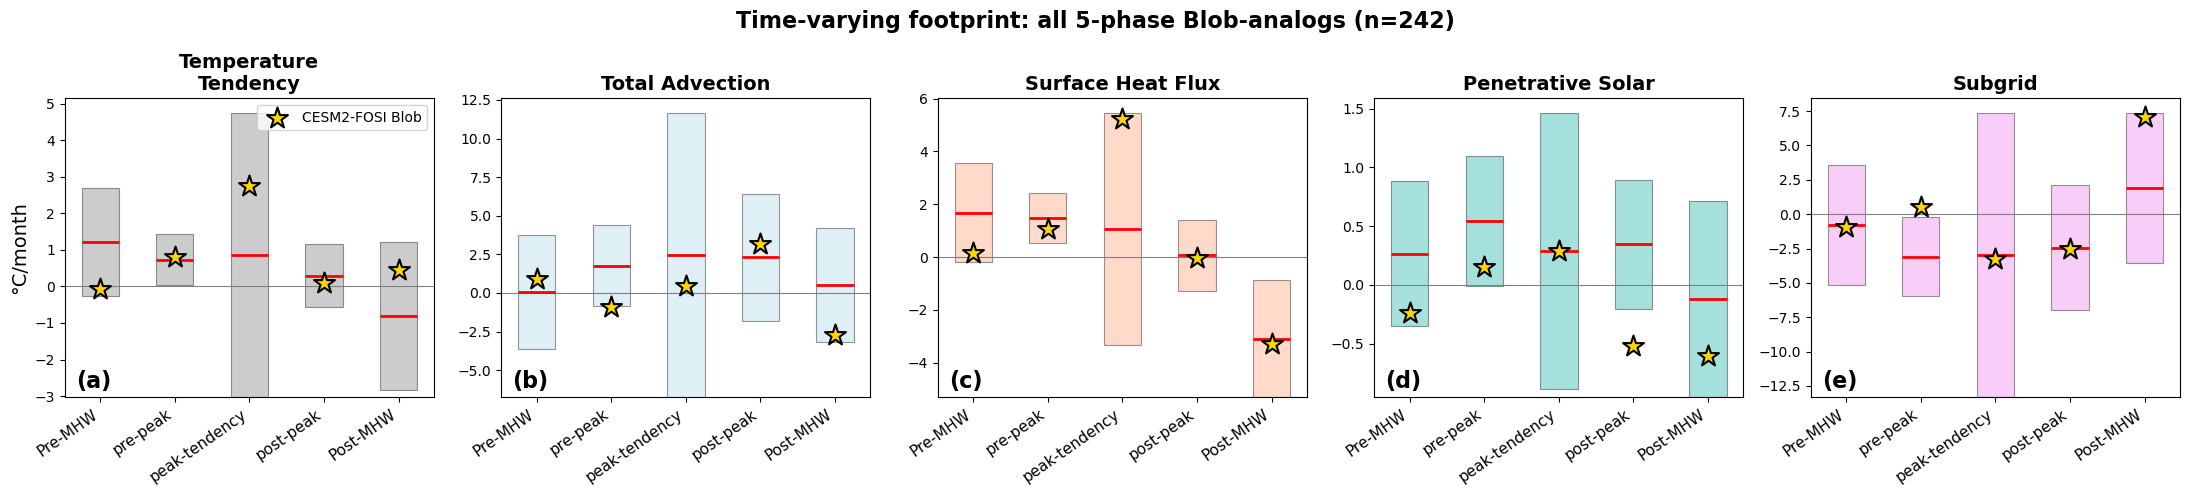

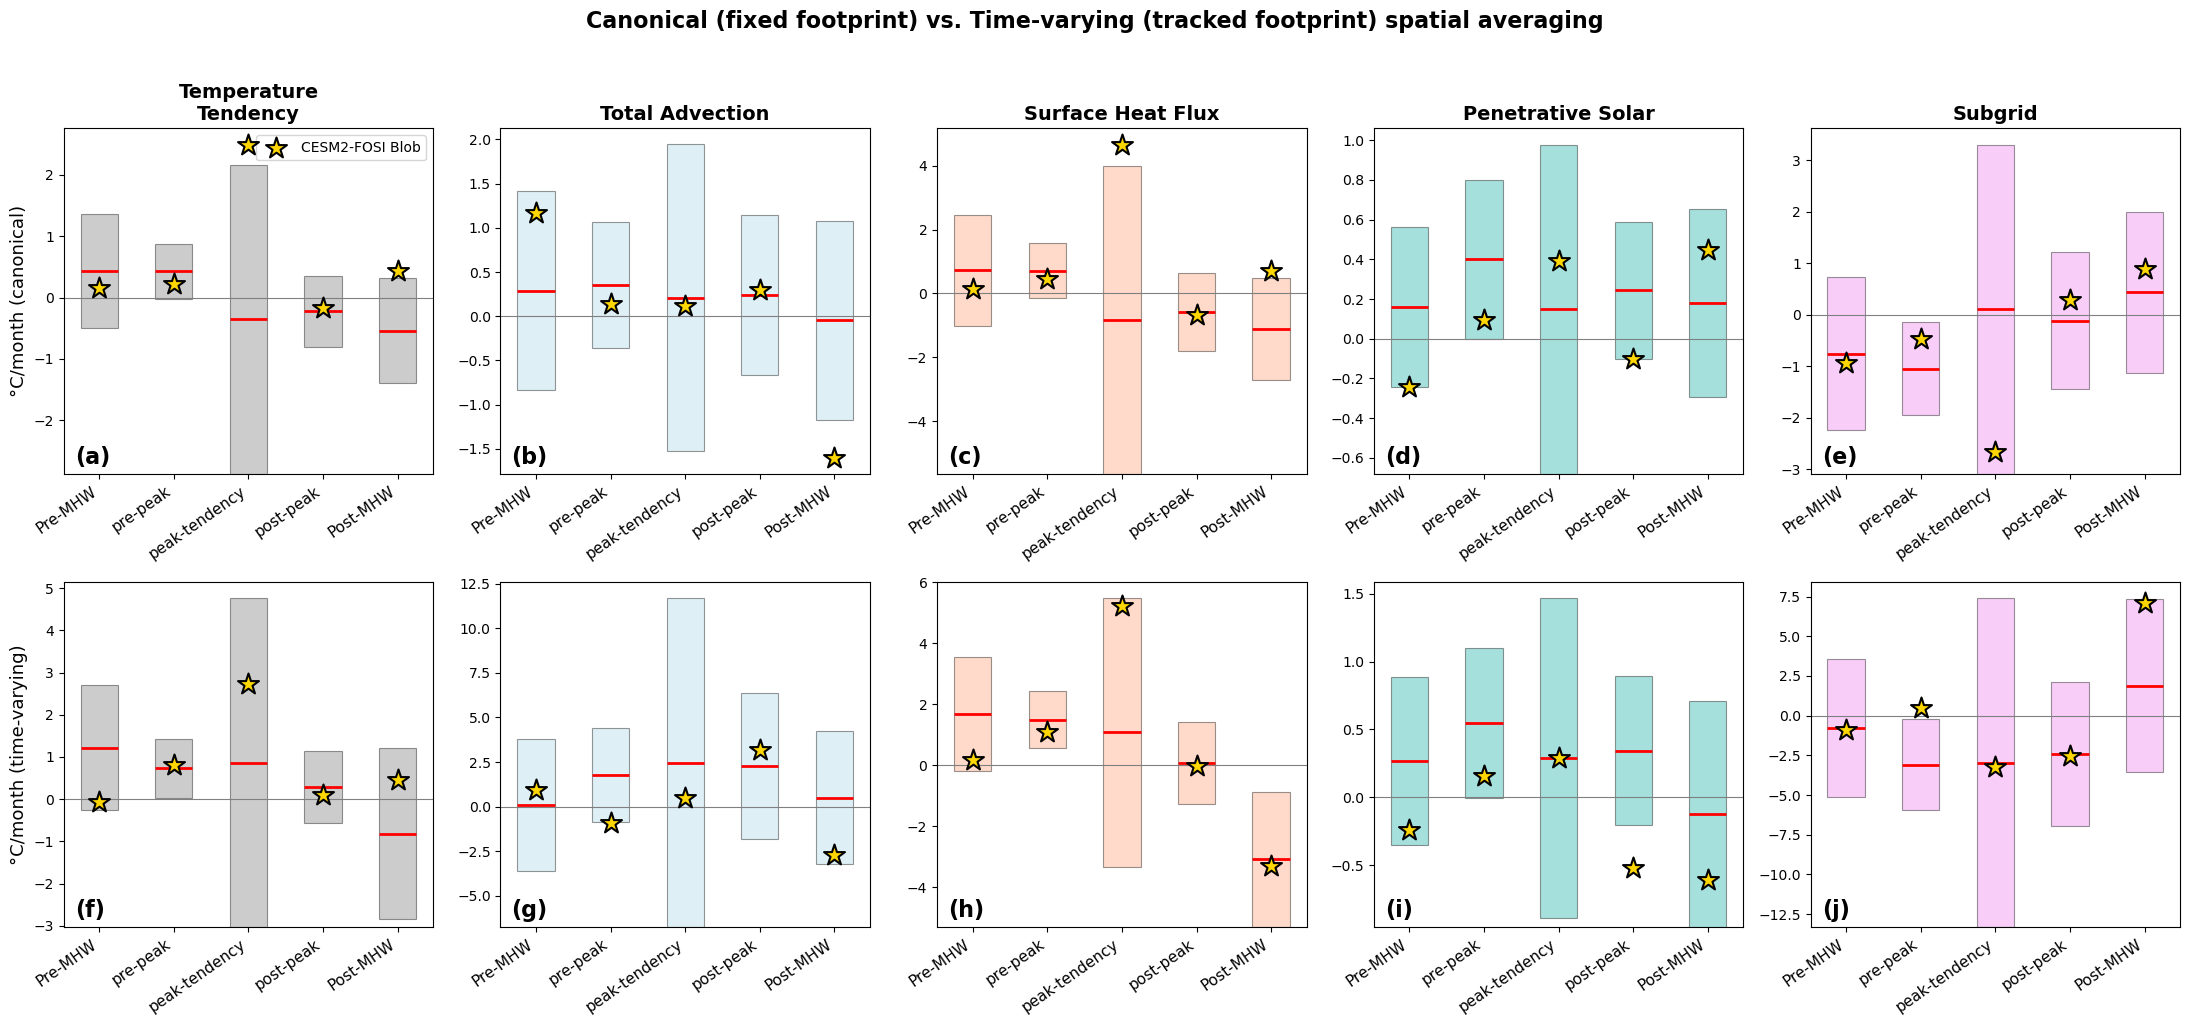

In [20]:
# ============================================================
# Check FOSI Blob's grid matches the labels grid (needed to reuse the same regridder)
# ============================================================
print("fosi_blobs lat/lon shape:", fosi_blobs.lat.shape, fosi_blobs.lon.shape)
print("labels_full lat/lon shape:", labels_full.lat.shape, labels_full.lon.shape)
print("VERIFY: these should match, since fosi_blobs and labels_full come from the same Ocetrac tracking grid")


# ============================================================
# Build the FOSI Blob's OWN time-varying heat budget profile
# (same logic as process_one_member_heat_budget_timevarying, but for the single FOSI Blob object)
# ============================================================
def build_fosi_timevarying_profile(fosi_hb_cropped, fosi_blobs, object_id, blob_times, regridder):
    padded_times = build_padded_time_window(fosi_hb_cropped['TOT_ADV'].time, blob_times)
    time_varying_mask = build_time_varying_mask_for_analog(fosi_blobs, object_id, blob_times, regridder)

    term_profiles = {}
    for term, da in fosi_hb_cropped.items():
        da_padded = da.sel(time=padded_times)
        masked_active = da_padded.sel(time=blob_times).where(time_varying_mask.sel(time=blob_times) == 1)
        first_mask = time_varying_mask.isel(time=0)
        last_mask = time_varying_mask.isel(time=-1)
        pre_times = padded_times[~padded_times.isin(blob_times) & (padded_times < blob_times[0])]
        post_times = padded_times[~padded_times.isin(blob_times) & (padded_times > blob_times[-1])]
        masked_pre = da_padded.sel(time=pre_times).where(first_mask == 1) if len(pre_times) > 0 else None
        masked_post = da_padded.sel(time=post_times).where(last_mask == 1) if len(post_times) > 0 else None

        pieces = [p for p in [masked_pre, masked_active, masked_post] if p is not None]
        full_masked = xr.concat(pieces, dim='time').sortby('time')
        term_profiles[term] = full_masked.mean(dim=('nlat_t', 'nlon_t')).compute()
    return term_profiles


fosi_hb_profile_timevarying = build_fosi_timevarying_profile(
    fosi_hb_cropped, fosi_blobs, object_id, blob_times, regridder
)

fosi_phases_5_timevarying, fosi_n_phases_tv, fosi_peak_date_tv = phase_split_adaptive(fosi_hb_profile_timevarying)
print(f"FOSI Blob (time-varying): {fosi_n_phases_tv}-phase, peak = {str(fosi_peak_date_tv)[:7]}")
for term in TERMS:
    print(f"{term}: canonical peak-tendency={fosi_phases_5[term]['peak-tendency']:.2f} | "
          f"time-varying peak-tendency={fosi_phases_5_timevarying[term]['peak-tendency']:.2f}")

blob_values_by_term_5_timevarying = {
    term: {p: fosi_phases_5_timevarying[term].get(p, np.nan) for p in PHASE_NAMES_5}
    for term in TERMS
}


# ============================================================
# Plot: time-varying composite, all 331 analogs, with FOSI Blob (time-varying) star
# ============================================================
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, term, letter in zip(axes, TERMS, panel_letters):
    plot_term_panel_with_blob(ax, term, PHASE_NAMES_5, composite_timevarying_all,
                               blob_values_by_term_5_timevarying[term], term_titles[term], term_colors[term])
    ax.text(0.03, 0.03, letter, transform=ax.transAxes, fontsize=16, fontweight='bold')
    if ax == axes[0]:
        ax.set_ylabel('°C/month', fontsize=14)
        ax.legend(fontsize=10, loc='upper right')
fig.suptitle(f'Time-varying footprint: all 5-phase Blob-analogs (n={len(keys_5phase_timevarying)})',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('Figure_heat_budget_timevarying_5panel.png', dpi=300, bbox_inches='tight')
plt.show()


# ============================================================
# Side-by-side comparison: canonical vs. time-varying, same 5 terms, 2 rows
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
for ax, term, letter in zip(axes[0], TERMS, panel_letters):
    plot_term_panel_with_blob(ax, term, PHASE_NAMES_5, composite_all_5phase,
                               blob_values_by_term_5[term], term_titles[term], term_colors[term])
    ax.text(0.03, 0.03, letter, transform=ax.transAxes, fontsize=16, fontweight='bold')
    if ax == axes[0, 0]:
        ax.set_ylabel('°C/month (canonical)', fontsize=13)
        ax.legend(fontsize=10, loc='upper right')

letters_row2 = ['(f)', '(g)', '(h)', '(i)', '(j)']
for ax, term, letter in zip(axes[1], TERMS, letters_row2):
    plot_term_panel_with_blob(ax, term, PHASE_NAMES_5, composite_timevarying_all,
                               blob_values_by_term_5_timevarying[term], '', term_colors[term])
    ax.text(0.03, 0.03, letter, transform=ax.transAxes, fontsize=16, fontweight='bold')
    if ax == axes[1, 0]:
        ax.set_ylabel('°C/month (time-varying)', fontsize=13)

fig.suptitle('Canonical (fixed footprint) vs. Time-varying (tracked footprint) spatial averaging',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Figure_heat_budget_canonical_vs_timevarying.png', dpi=300, bbox_inches='tight')
plt.show()

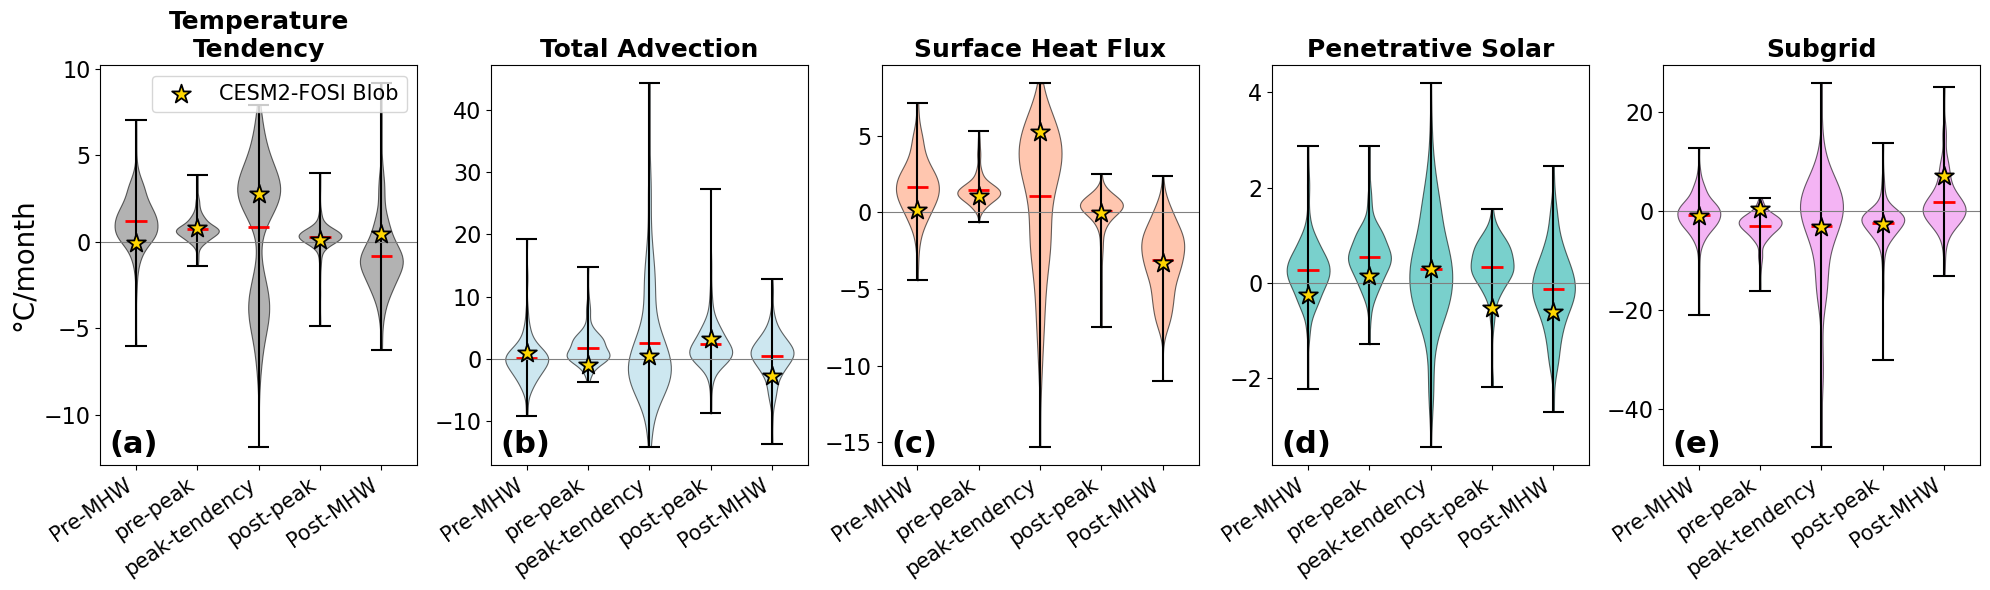

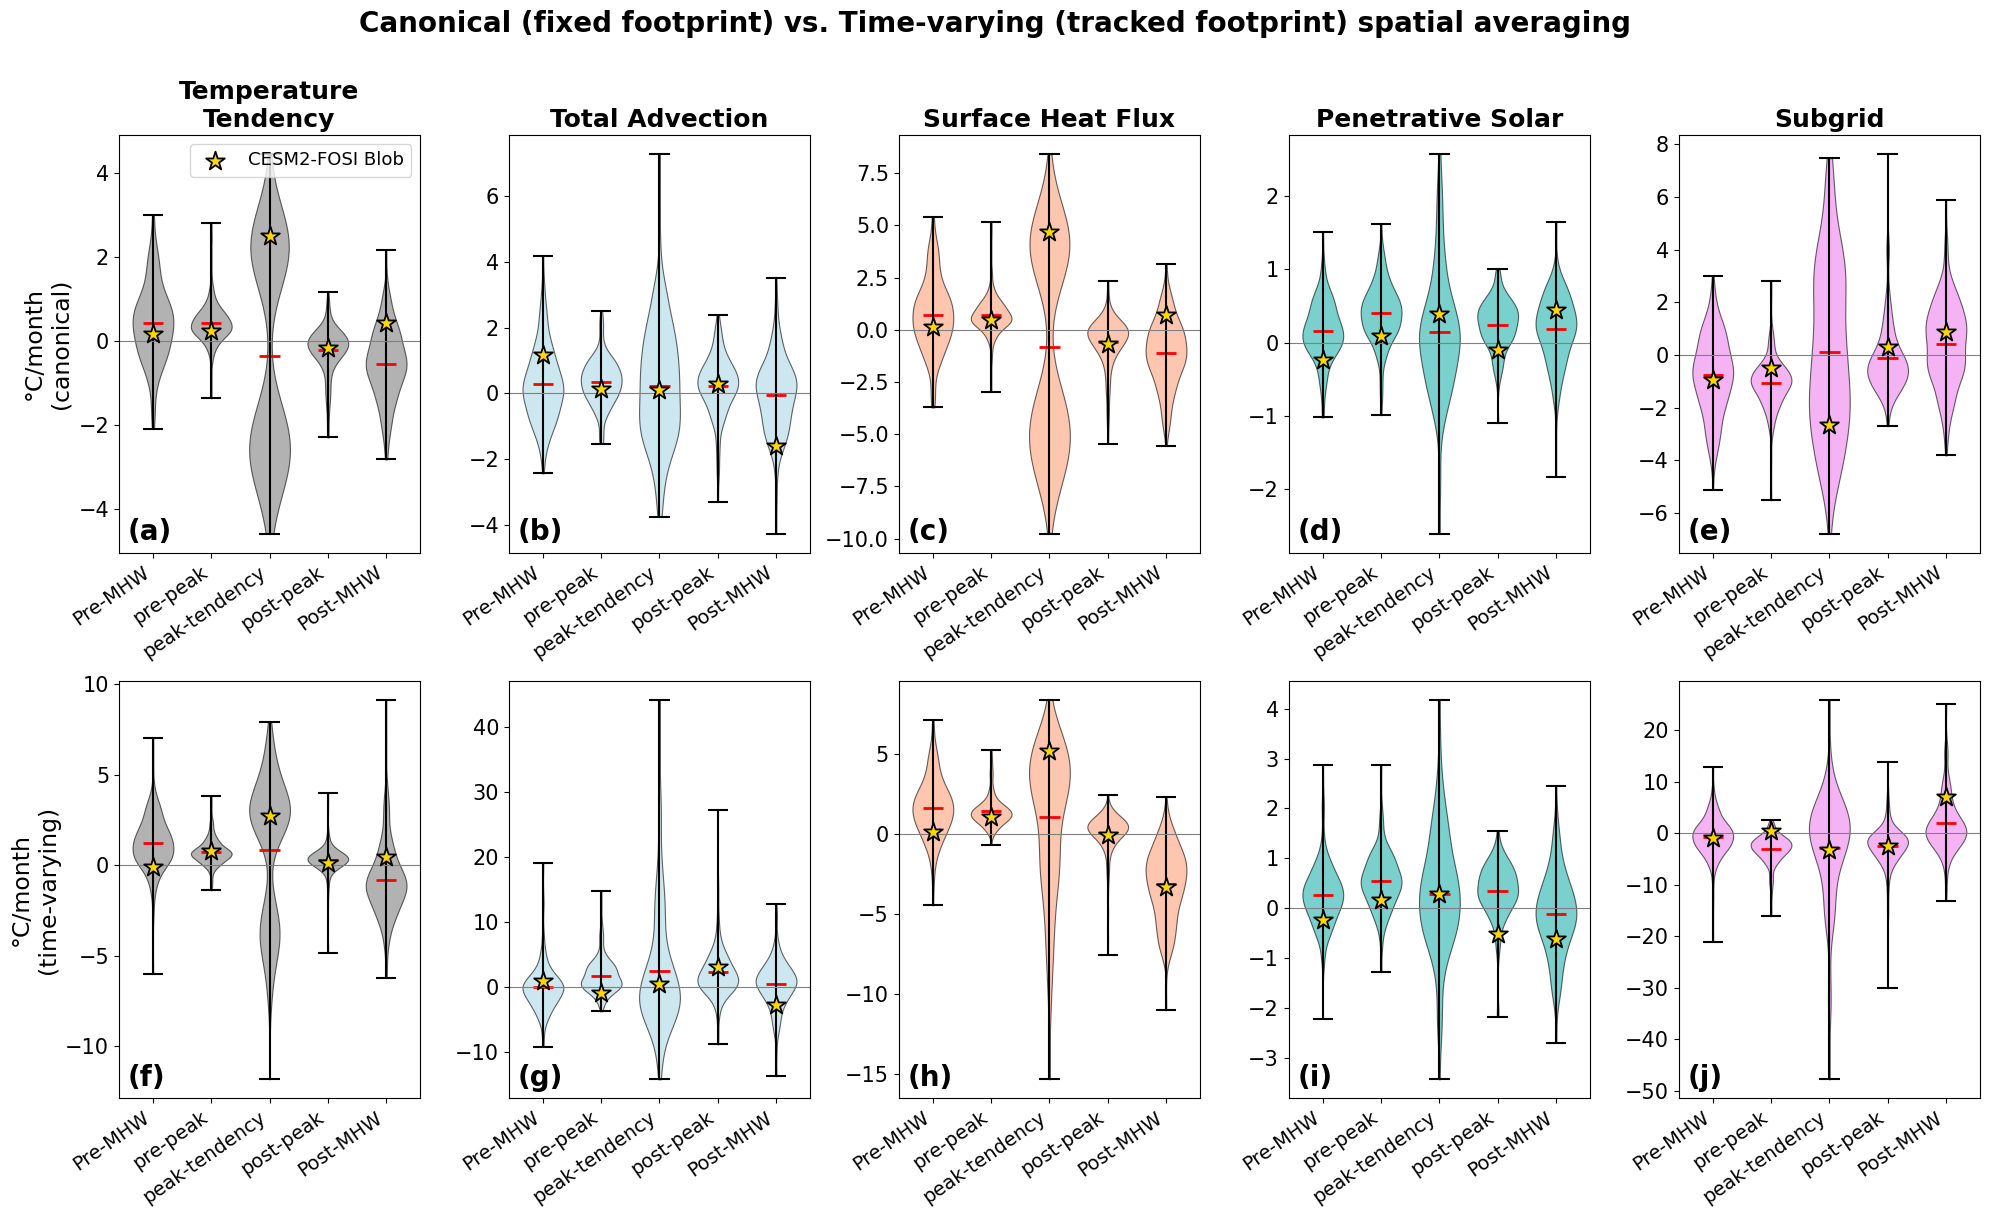

In [21]:
def plot_term_panel_violin_with_blob(ax, term, phase_names, keys, hb_phases_all, blob_values, title, color):
    individual_vals = get_individual_values_by_phase(keys, hb_phases_all, term, phase_names)
    data_for_violin = [individual_vals[p] for p in phase_names]
    positions = np.arange(len(phase_names))

    parts = ax.violinplot(data_for_violin, positions=positions, showmeans=True, showmedians=False, widths=0.7)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.6)
        pc.set_edgecolor('k')
        pc.set_linewidth(0.8)
    parts['cmeans'].set_color('red')
    parts['cmeans'].set_linewidth(2)
    parts['cbars'].set_color('k')
    parts['cmins'].set_color('k')
    parts['cmaxes'].set_color('k')

    for i, phase in enumerate(phase_names):
        if phase in blob_values and not np.isnan(blob_values[phase]):
            ax.scatter(i, blob_values[phase], color='gold', edgecolor='black', s=200,
                       marker='*', zorder=20, linewidth=1.3, label='CESM2-FOSI Blob' if i == 0 else None)

    ax.axhline(0, color='gray', linewidth=0.8)
    ax.set_xticks(positions)
    ax.set_xticklabels(phase_names, fontsize=13, rotation=35, ha='right')
    ax.set_title(title, fontsize=18, fontweight='bold')


# ============================================================
# Violin: time-varying composite, all 5-phase analogs, FOSI Blob (time-varying) star
# ============================================================
fig, axes = plt.subplots(1, 5, figsize=(20, 6))
for ax, term, letter in zip(axes, TERMS, panel_letters):
    plot_term_panel_violin_with_blob(ax, term, PHASE_NAMES_5, keys_5phase_timevarying, hb_phases_timevarying,
                                      blob_values_by_term_5_timevarying[term], term_titles[term], term_colors[term])
    ax.text(0.03, 0.03, letter, transform=ax.transAxes, fontsize=22, fontweight='bold')
    ax.tick_params(axis='y', labelsize=16)
    ax.tick_params(axis='x', labelsize=15)
    if ax == axes[0]:
        ax.set_ylabel('°C/month', fontsize=20)
        ax.legend(fontsize=15, loc='upper right', frameon=True)
plt.tight_layout()
plt.savefig('Figure_heat_budget_timevarying_violin.png', dpi=300, bbox_inches='tight')
plt.show()


# ============================================================
# Side-by-side violin: canonical (row 1) vs. time-varying (row 2)
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(20, 12))

for ax, term, letter in zip(axes[0], TERMS, panel_letters):
    plot_term_panel_violin_with_blob(ax, term, PHASE_NAMES_5, keys_5phase, hb_phases_all,
                                      blob_values_by_term_5[term], term_titles[term], term_colors[term])
    ax.text(0.03, 0.03, letter, transform=ax.transAxes, fontsize=20, fontweight='bold')
    ax.tick_params(axis='y', labelsize=15)
    ax.tick_params(axis='x', labelsize=14)
    if ax == axes[0, 0]:
        ax.set_ylabel('°C/month\n(canonical)', fontsize=17)
        ax.legend(fontsize=13, loc='upper right', frameon=True)

letters_row2 = ['(f)', '(g)', '(h)', '(i)', '(j)']
for ax, term, letter in zip(axes[1], TERMS, letters_row2):
    plot_term_panel_violin_with_blob(ax, term, PHASE_NAMES_5, keys_5phase_timevarying, hb_phases_timevarying,
                                      blob_values_by_term_5_timevarying[term], '', term_colors[term])
    ax.text(0.03, 0.03, letter, transform=ax.transAxes, fontsize=20, fontweight='bold')
    ax.tick_params(axis='y', labelsize=15)
    ax.tick_params(axis='x', labelsize=14)
    if ax == axes[1, 0]:
        ax.set_ylabel('°C/month\n(time-varying)', fontsize=17)

fig.suptitle('Canonical (fixed footprint) vs. Time-varying (tracked footprint) spatial averaging',
             fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('Figure_heat_budget_canonical_vs_timevarying_violin.png', dpi=300, bbox_inches='tight')
plt.show()

Time-varying: 159 warming-peak, 83 cooling-peak


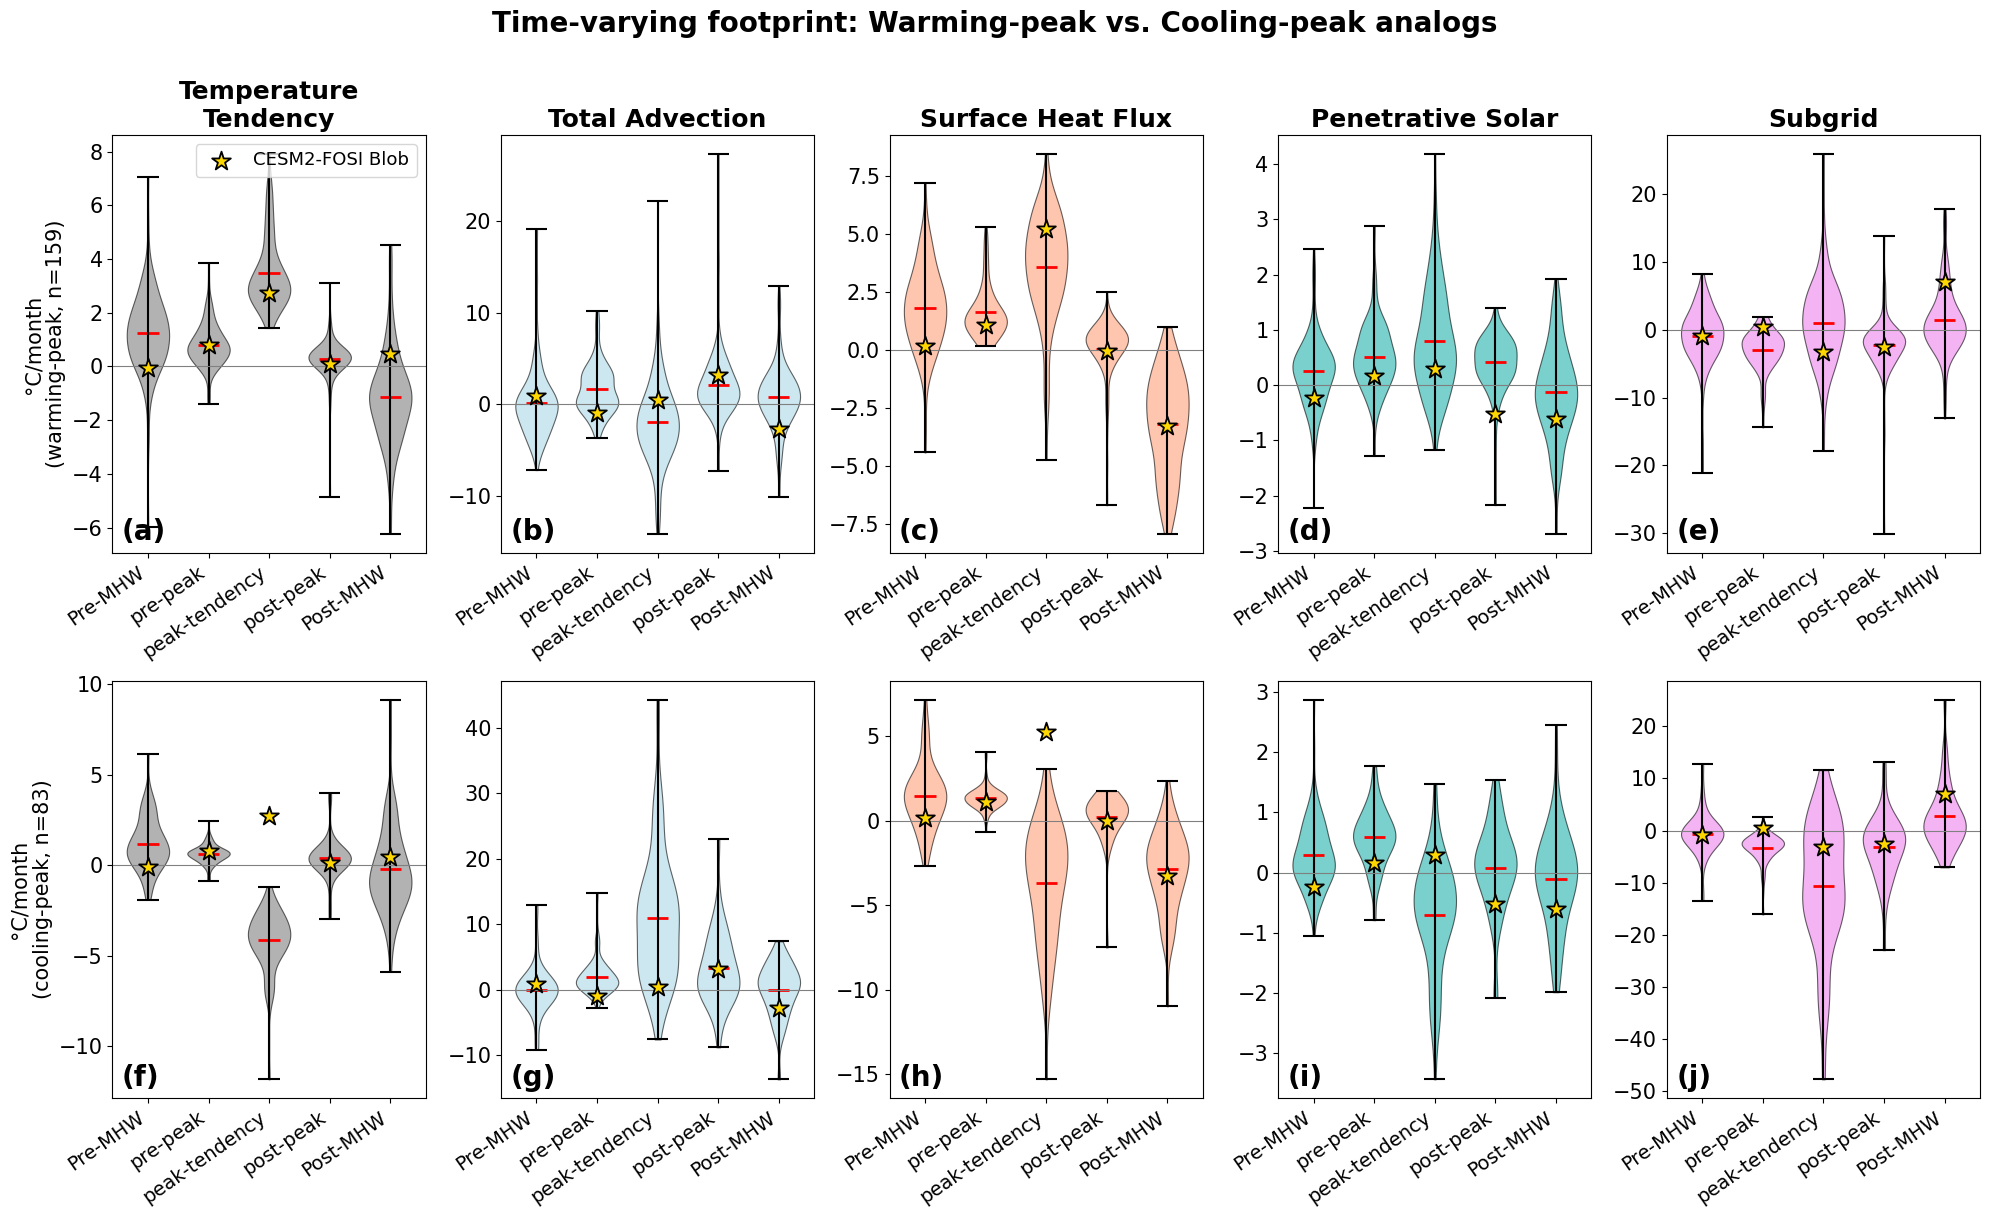


=== Peak-tendency, split by warming/cooling, canonical vs. time-varying ===
TEND_TEMP:
  warming: canonical=2.25±0.55 (n=113) | time-varying=3.49±1.32 (n=159)
  cooling: canonical=-2.64±0.66 (n=129) | time-varying=-4.16±1.61 (n=83)
TOT_ADV:
  warming: canonical=-0.11±1.46 (n=113) | time-varying=-1.94±4.80 (n=159)
  cooling: canonical=0.50±1.90 (n=129) | time-varying=10.88±9.79 (n=83)
SHF_depth:
  warming: canonical=4.14±1.19 (n=113) | time-varying=3.56±2.26 (n=159)
  cooling: canonical=-5.17±1.46 (n=129) | time-varying=-3.68±3.50 (n=83)
QSW_3D:
  warming: canonical=0.68±0.73 (n=113) | time-varying=0.80±0.95 (n=159)
  cooling: canonical=-0.32±0.59 (n=129) | time-varying=-0.70±0.93 (n=83)
SUBGRID:
  warming: canonical=-2.46±1.72 (n=113) | time-varying=1.06±5.93 (n=159)
  cooling: canonical=2.35±2.40 (n=129) | time-varying=-10.68±12.45 (n=83)


In [22]:
# ============================================================
# Split time-varying population into warming-peak / cooling-peak
# ============================================================
warming_keys_timevarying, cooling_keys_timevarying = separate_peak_by_sign(
    keys_5phase_timevarying, hb_phases_timevarying
)
print(f"Time-varying: {len(warming_keys_timevarying)} warming-peak, {len(cooling_keys_timevarying)} cooling-peak")

composite_warming_timevarying = composite_phase_group(warming_keys_timevarying, hb_phases_timevarying, PHASE_NAMES_5)
composite_cooling_timevarying = composite_phase_group(cooling_keys_timevarying, hb_phases_timevarying, PHASE_NAMES_5)


# ============================================================
# Violin: time-varying, warming-peak (row 1) vs. cooling-peak (row 2)
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(20, 12))

for ax, term, letter in zip(axes[0], TERMS, panel_letters):
    plot_term_panel_violin_with_blob(ax, term, PHASE_NAMES_5, warming_keys_timevarying, hb_phases_timevarying,
                                      blob_values_by_term_5_timevarying[term], term_titles[term], term_colors[term])
    ax.text(0.03, 0.03, letter, transform=ax.transAxes, fontsize=20, fontweight='bold')
    ax.tick_params(axis='y', labelsize=15)
    ax.tick_params(axis='x', labelsize=14)
    if ax == axes[0, 0]:
        ax.set_ylabel(f'°C/month\n(warming-peak, n={len(warming_keys_timevarying)})', fontsize=15)
        ax.legend(fontsize=13, loc='upper right', frameon=True)

letters_row2 = ['(f)', '(g)', '(h)', '(i)', '(j)']
for ax, term, letter in zip(axes[1], TERMS, letters_row2):
    plot_term_panel_violin_with_blob(ax, term, PHASE_NAMES_5, cooling_keys_timevarying, hb_phases_timevarying,
                                      blob_values_by_term_5_timevarying[term], '', term_colors[term])
    ax.text(0.03, 0.03, letter, transform=ax.transAxes, fontsize=20, fontweight='bold')
    ax.tick_params(axis='y', labelsize=15)
    ax.tick_params(axis='x', labelsize=14)
    if ax == axes[1, 0]:
        ax.set_ylabel(f'°C/month\n(cooling-peak, n={len(cooling_keys_timevarying)})', fontsize=15)

fig.suptitle('Time-varying footprint: Warming-peak vs. Cooling-peak analogs', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('Figure_heat_budget_timevarying_warming_vs_cooling_violin.png', dpi=300, bbox_inches='tight')
plt.show()


# ============================================================
# Numeric comparison: canonical vs time-varying, warming vs cooling, at peak-tendency
# ============================================================
print("\n=== Peak-tendency, split by warming/cooling, canonical vs. time-varying ===")
for term in TERMS:
    cw_mean, cw_std, cw_n = composite_warming[term]['peak-tendency']
    cc_mean, cc_std, cc_n = composite_cooling[term]['peak-tendency']
    tw_mean, tw_std, tw_n = composite_warming_timevarying[term]['peak-tendency']
    tc_mean, tc_std, tc_n = composite_cooling_timevarying[term]['peak-tendency']
    print(f"{term}:")
    print(f"  warming: canonical={cw_mean:.2f}±{cw_std:.2f} (n={cw_n}) | time-varying={tw_mean:.2f}±{tw_std:.2f} (n={tw_n})")
    print(f"  cooling: canonical={cc_mean:.2f}±{cc_std:.2f} (n={cc_n}) | time-varying={tc_mean:.2f}±{tc_std:.2f} (n={tc_n})")

In [23]:
# ============================================================
# Check: for shared keys, did the peak-tendency MONTH shift between
# canonical and time-varying averaging?
# ============================================================
shared_keys = set(hb_phases_all.keys()) & set(hb_phases_timevarying.keys())
month_shifted = 0
for key in shared_keys:
    canon_peak = hb_phases_all[key]['peak_date']
    tv_peak = hb_phases_timevarying[key]['peak_date']
    if canon_peak is not None and tv_peak is not None and canon_peak != tv_peak:
        month_shifted += 1
print(f"Analogs where peak-tendency MONTH differs between canonical and time-varying: {month_shifted} / {len(shared_keys)}")

Analogs where peak-tendency MONTH differs between canonical and time-varying: 179 / 331


In [24]:
# ============================================================
# Check for outliers: median/IQR vs mean/std for the two flagged term/group combos
# ============================================================
for term, keys, label in [('TOT_ADV', cooling_keys_timevarying, 'cooling'), ('SUBGRID', cooling_keys_timevarying, 'cooling')]:
    vals = np.array(get_individual_values_by_phase(keys, hb_phases_timevarying, term, ['peak-tendency'])['peak-tendency'])
    print(f"\n{term} ({label}, time-varying), n={len(vals)}:")
    print(f"  mean={vals.mean():.2f}, std={vals.std():.2f}")
    print(f"  median={np.median(vals):.2f}, IQR=[{np.percentile(vals,25):.2f}, {np.percentile(vals,75):.2f}]")
    print(f"  min={vals.min():.2f}, max={vals.max():.2f}")
    sorted_vals = np.sort(np.abs(vals))[::-1]
    print(f"  5 most extreme |values|: {sorted_vals[:5]}")


TOT_ADV (cooling, time-varying), n=83:
  mean=10.88, std=9.79
  median=10.44, IQR=[3.04, 15.15]
  min=-7.57, max=44.25
  5 most extreme |values|: [44.25479561 40.55089752 31.58133513 28.87594774 28.44524515]

SUBGRID (cooling, time-varying), n=83:
  mean=-10.68, std=12.45
  median=-11.00, IQR=[-16.81, -0.33]
  min=-47.74, max=11.61
  5 most extreme |values|: [47.74468437 45.37671511 35.48240847 34.87202347 33.40829734]


In [25]:
# ============================================================
# Inspect the most extreme cooling-peak SUBGRID analog directly
# ============================================================
subgrid_vals = np.array(get_individual_values_by_phase(cooling_keys_timevarying, hb_phases_timevarying, 'SUBGRID', ['peak-tendency'])['peak-tendency'])
extreme_idx = np.argmin(subgrid_vals)  # most negative, i.e. the -47.74 case
extreme_key = [k for k in cooling_keys_timevarying][extreme_idx]
print(f"Most extreme analog: {extreme_key}, SUBGRID peak-tendency = {subgrid_vals[extreme_idx]:.2f}")

member_id, analog_id = extreme_key
member_labels = labels_full.isel(ensemble_member=member_id)
mask = (member_labels == analog_id)
times_present = member_labels.time.where(mask.any(dim=('lat', 'lon')), drop=True)

tv_mask = build_time_varying_mask_for_analog(member_labels, analog_id, times_present, regridder)
n_valid_per_month = tv_mask.sum(dim=('nlat_t', 'nlon_t')).values
print(f"Time-varying footprint size per month: {n_valid_per_month}")
print(f"Peak-tendency month index (within padded window): check against phase_split_adaptive's peak_idx_global")
print(f"Peak date: {hb_phases_timevarying[extreme_key]['peak_date']}")

Most extreme analog: (30, 2.0), SUBGRID peak-tendency = -47.74
Time-varying footprint size per month: [ 759  797  884 1118  925 1301 1111 1175 3020 4779 4040 3637 1037]
Peak-tendency month index (within padded window): check against phase_split_adaptive's peak_idx_global
Peak date: 1980-01-01 00:00:00


In [26]:
# Check if the size volatility exists BEFORE regridding (on the original labels grid)
mask_original_grid = mask.sel(time=times_present)
n_valid_original = mask_original_grid.sum(dim=('lat', 'lon')).values
print(f"Original (pre-regrid) footprint size per month: {n_valid_original}")

Original (pre-regrid) footprint size per month: [ 440  450  495  569  518  724  589  615 1118 2024 1203  876  263]


In [23]:
# ============================================================
# Check: boundary edge cases in peak-tendency identification
# ============================================================
n_boundary_prepeak_nan = 0
n_boundary_postpeak_nan = 0
for key in keys_5phase:
    phases = hb_phases_all[key]['phases']
    if np.isnan(phases['TEND_TEMP']['pre-peak']):
        n_boundary_prepeak_nan += 1
    if np.isnan(phases['TEND_TEMP']['post-peak']):
        n_boundary_postpeak_nan += 1

print(f"Analogs with peak-tendency at the START of core window (pre-peak undefined): {n_boundary_prepeak_nan} / {len(keys_5phase)}")
print(f"Analogs with peak-tendency at the END of core window (post-peak undefined): {n_boundary_postpeak_nan} / {len(keys_5phase)}")

Analogs with peak-tendency at the START of core window (pre-peak undefined): 28 / 242
Analogs with peak-tendency at the END of core window (post-peak undefined): 37 / 242


In [24]:
# ============================================================
# How many analogs are affected in total (union), and do boundary
# cases skew toward warming-peak or cooling-peak?
# ============================================================
prepeak_nan_keys = set()
postpeak_nan_keys = set()
for key in keys_5phase:
    phases = hb_phases_all[key]['phases']
    if np.isnan(phases['TEND_TEMP']['pre-peak']):
        prepeak_nan_keys.add(key)
    if np.isnan(phases['TEND_TEMP']['post-peak']):
        postpeak_nan_keys.add(key)

both_nan = prepeak_nan_keys & postpeak_nan_keys
either_nan = prepeak_nan_keys | postpeak_nan_keys
print(f"Missing BOTH pre-peak and post-peak: {len(both_nan)} / {len(keys_5phase)}")
print(f"Missing EITHER pre-peak or post-peak: {len(either_nan)} / {len(keys_5phase)} ({100*len(either_nan)/len(keys_5phase):.1f}%)")

warming_set = set(warming_keys)
cooling_set = set(cooling_keys)
print(f"\nOf {len(prepeak_nan_keys)} missing pre-peak: "
      f"{len(prepeak_nan_keys & warming_set)} warming, {len(prepeak_nan_keys & cooling_set)} cooling")
print(f"Of {len(postpeak_nan_keys)} missing post-peak: "
      f"{len(postpeak_nan_keys & warming_set)} warming, {len(postpeak_nan_keys & cooling_set)} cooling")
print(f"\nFor reference, overall split: {len(warming_keys)} warming, {len(cooling_keys)} cooling "
      f"({100*len(warming_keys)/len(keys_5phase):.1f}% warming)")

Missing BOTH pre-peak and post-peak: 0 / 242
Missing EITHER pre-peak or post-peak: 65 / 242 (26.9%)

Of 28 missing pre-peak: 28 warming, 0 cooling
Of 37 missing post-peak: 1 warming, 36 cooling

For reference, overall split: 113 warming, 129 cooling (46.7% warming)


In [26]:
# ============================================================
# Load SSTa (needed for the peak-SSTa vs peak-tendency comparison only)
# ============================================================
ssta_varnames = {
    'linear': '__xarray_dataarray_variable__',
    'quadratic': '__xarray_dataarray_variable__',
    'ensmean': 'SST',
    'noseas': '__xarray_dataarray_variable__',
}

ssta_notrend_by_method = {}
for method, base_path in base_paths.items():
    ssta_paths = [f'{base_path}/ens_{i}_ssta.nc' for i in range(100)]
    ssta_notrend_by_method[method] = xr.open_mfdataset(ssta_paths, combine='nested', concat_dim='ensemble_member').compute()

print("SSTa loaded:", {m: ssta_notrend_by_method[m].sizes for m in base_paths})

SSTa loaded: {'linear': Frozen({'ensemble_member': 100, 'time': 528, 'lat': 64, 'lon': 81}), 'quadratic': Frozen({'ensemble_member': 100, 'time': 528, 'lat': 64, 'lon': 81}), 'ensmean': Frozen({'ensemble_member': 100, 'time': 528, 'lat': 64, 'lon': 81}), 'noseas': Frozen({'ensemble_member': 100, 'time': 528, 'lat': 64, 'lon': 81})}


In [27]:
# ============================================================
# Empirical test: what if "peak" = month of max SSTa instead of max |tendency|?
# Uses each analog's own tracked-footprint SSTa (same grid/mask as Section 3.2)
# ============================================================
def get_ssta_profile_for_analog(member_labels, member_ssta, analog_id, times_present, pre_post_months=2):
    """Area-averaged SSTa over the analog's own tracked footprint, for the padded window."""
    full_time_index = member_labels.time
    padded_times = build_padded_time_window(full_time_index, times_present)
    mask_padded = (member_labels.sel(time=padded_times) == analog_id)
    # For pre/post-MHW padding months (where the object isn't tracked), use first/last active mask
    first_mask = (member_labels.sel(time=times_present[0]) == analog_id)
    last_mask = (member_labels.sel(time=times_present[-1]) == analog_id)
    ssta_padded = member_ssta.sel(time=padded_times)

    ssta_vals = []
    for t in padded_times.values:
        if t in times_present.values:
            m = (member_labels.sel(time=t) == analog_id)
        elif t < times_present.values[0]:
            m = first_mask
        else:
            m = last_mask
        ssta_vals.append(float(ssta_padded.sel(time=t).where(m).mean()))

    return xr.DataArray(ssta_vals, dims='time', coords={'time': padded_times})


def compare_peak_definitions(member_labels, member_ssta, analog_id, term_profiles, pre_post_months=2, min_months_for_5phase=8):
    """
    Compare peak-tendency month (max |TEND_TEMP|) vs. peak-SSTa month (max SSTa),
    for one analog. Returns whether they match, and TEND_TEMP at the SSTa-peak month.
    """
    mask = (member_labels == analog_id)
    times_present = member_labels.time.where(mask.any(dim=('lat', 'lon')), drop=True)
    if len(times_present) == 0:
        return None

    ssta_profile = get_ssta_profile_for_analog(member_labels, member_ssta, analog_id, times_present, pre_post_months)

    n_total = len(ssta_profile.time)
    core_start = pre_post_months
    core_end = n_total - pre_post_months
    if core_end - core_start < min_months_for_5phase:
        return None  # only compare for 5-phase-eligible events

    tend_temp = term_profiles['TEND_TEMP']
    core_tend = tend_temp.isel(time=slice(core_start, core_end))
    peak_tendency_idx = core_start + int(np.abs(core_tend.values).argmax())

    core_ssta = ssta_profile.isel(time=slice(core_start, core_end))
    peak_ssta_idx = core_start + int(core_ssta.values.argmax())

    tend_at_ssta_peak = float(tend_temp.isel(time=peak_ssta_idx))
    months_apart = peak_ssta_idx - peak_tendency_idx

    return {
        'same_month': peak_tendency_idx == peak_ssta_idx,
        'months_apart': months_apart,
        'tend_at_tendency_peak': float(tend_temp.isel(time=peak_tendency_idx)),
        'tend_at_ssta_peak': tend_at_ssta_peak,
    }


# ============================================================
# Run across all 5-phase analogs (need ssta_notrend_by_method from Section 3.2 -- reload if needed)
# ============================================================
comparison_results = {}
for member_id in range(100):
    member_labels_i = labels_full.isel(ensemble_member=member_id)
    member_ssta_i = ssta_notrend_by_method['linear'][ssta_varnames['linear']].isel(ensemble_member=member_id)
    for analog_id in blob_analog_ids['linear'][member_id]:
        key = (member_id, analog_id)
        if key not in heat_budget_profiles_all:
            continue
        result = compare_peak_definitions(
            member_labels_i, member_ssta_i, analog_id, heat_budget_profiles_all[key]['terms']
        )
        if result is not None:
            comparison_results[key] = result

print(f"Compared {len(comparison_results)} five-phase analogs")

n_same_month = sum(1 for r in comparison_results.values() if r['same_month'])
print(f"\nPeak-tendency month == peak-SSTa month: {n_same_month} / {len(comparison_results)} "
      f"({100*n_same_month/len(comparison_results):.1f}%)")

tend_at_ssta_peak_vals = np.array([r['tend_at_ssta_peak'] for r in comparison_results.values()])
tend_at_tendency_peak_vals = np.array([r['tend_at_tendency_peak'] for r in comparison_results.values()])
print(f"\n|TEND_TEMP| at peak-SSTa month: mean={np.abs(tend_at_ssta_peak_vals).mean():.3f}, "
      f"median={np.median(np.abs(tend_at_ssta_peak_vals)):.3f}")
print(f"|TEND_TEMP| at peak-tendency month: mean={np.abs(tend_at_tendency_peak_vals).mean():.3f}, "
      f"median={np.median(np.abs(tend_at_tendency_peak_vals)):.3f}")
print(f"\nRatio (peak-SSTa tendency / peak-tendency tendency): "
      f"{np.abs(tend_at_ssta_peak_vals).mean() / np.abs(tend_at_tendency_peak_vals).mean():.2f}")

Compared 242 five-phase analogs

Peak-tendency month == peak-SSTa month: 11 / 242 (4.5%)

|TEND_TEMP| at peak-SSTa month: mean=0.904, median=0.768
|TEND_TEMP| at peak-tendency month: mean=2.460, median=2.391

Ratio (peak-SSTa tendency / peak-tendency tendency): 0.37


In [28]:
# ============================================================
# How many months apart, typically, is peak-SSTa from peak-tendency?
# months_apart = peak_ssta_idx - peak_tendency_idx
# positive = SSTa peak comes AFTER tendency peak; negative = before
# ============================================================
months_apart_vals = np.array([r['months_apart'] for r in comparison_results.values()])

print(f"Mean months apart: {months_apart_vals.mean():.2f}")
print(f"Median months apart: {np.median(months_apart_vals):.2f}")
print(f"Mean |months apart| (magnitude, ignoring direction): {np.abs(months_apart_vals).mean():.2f}")
print(f"Median |months apart|: {np.median(np.abs(months_apart_vals)):.2f}")

n_positive = np.sum(months_apart_vals > 0)
n_negative = np.sum(months_apart_vals < 0)
n_zero = np.sum(months_apart_vals == 0)
print(f"\nSSTa peak AFTER tendency peak: {n_positive} ({100*n_positive/len(months_apart_vals):.1f}%)")
print(f"SSTa peak BEFORE tendency peak: {n_negative} ({100*n_negative/len(months_apart_vals):.1f}%)")
print(f"Same month: {n_zero} ({100*n_zero/len(months_apart_vals):.1f}%)")

Mean months apart: -0.31
Median months apart: -1.00
Mean |months apart| (magnitude, ignoring direction): 5.50
Median |months apart|: 4.50

SSTa peak AFTER tendency peak: 105 (43.4%)
SSTa peak BEFORE tendency peak: 126 (52.1%)
Same month: 11 (4.5%)


In [29]:
# ============================================================
# Split months_apart by warming-peak vs. cooling-peak
# ============================================================
warming_set = set(warming_keys)
cooling_set = set(cooling_keys)

months_apart_warming = np.array([r['months_apart'] for k, r in comparison_results.items() if k in warming_set])
months_apart_cooling = np.array([r['months_apart'] for k, r in comparison_results.items() if k in cooling_set])

for label, vals in [('Warming-peak', months_apart_warming), ('Cooling-peak', months_apart_cooling)]:
    print(f"\n=== {label} (n={len(vals)}) ===")
    print(f"Mean months apart: {vals.mean():.2f}")
    print(f"Median months apart: {np.median(vals):.2f}")
    print(f"Mean |months apart|: {np.abs(vals).mean():.2f}")
    print(f"Median |months apart|: {np.median(np.abs(vals)):.2f}")
    n_pos = np.sum(vals > 0)
    n_neg = np.sum(vals < 0)
    n_zero = np.sum(vals == 0)
    print(f"SSTa peak AFTER tendency peak: {n_pos} ({100*n_pos/len(vals):.1f}%)")
    print(f"SSTa peak BEFORE tendency peak: {n_neg} ({100*n_neg/len(vals):.1f}%)")
    print(f"Same month: {n_zero} ({100*n_zero/len(vals):.1f}%)")


=== Warming-peak (n=113) ===
Mean months apart: 3.73
Median months apart: 4.00
Mean |months apart|: 5.84
Median |months apart|: 5.00
SSTa peak AFTER tendency peak: 84 (74.3%)
SSTa peak BEFORE tendency peak: 22 (19.5%)
Same month: 7 (6.2%)

=== Cooling-peak (n=129) ===
Mean months apart: -3.84
Median months apart: -4.00
Mean |months apart|: 5.19
Median |months apart|: 4.00
SSTa peak AFTER tendency peak: 21 (16.3%)
SSTa peak BEFORE tendency peak: 104 (80.6%)
Same month: 4 (3.1%)


In [30]:
print("=== SUBGRID magnitude vs. other terms, all phases, warming vs cooling ===")
for phase in PHASE_NAMES_5:
    print(f"\n--- {phase} ---")
    for term in TERMS:
        w_mean, w_std, w_n = composite_warming[term][phase]
        c_mean, c_std, c_n = composite_cooling[term][phase]
        print(f"  {term}: warming={w_mean:.2f}±{w_std:.2f} | cooling={c_mean:.2f}±{c_std:.2f}")

=== SUBGRID magnitude vs. other terms, all phases, warming vs cooling ===

--- Pre-MHW ---
  TEND_TEMP: warming=0.54±0.97 | cooling=0.33±0.87
  TOT_ADV: warming=0.23±1.02 | cooling=0.34±1.21
  SHF_depth: warming=0.93±1.80 | cooling=0.56±1.66
  QSW_3D: warming=0.14±0.40 | cooling=0.18±0.40
  SUBGRID: warming=-0.76±1.44 | cooling=-0.75±1.52

--- pre-peak ---
  TEND_TEMP: warming=0.44±0.60 | cooling=0.42±0.30
  TOT_ADV: warming=0.46±0.86 | cooling=0.29±0.59
  SHF_depth: warming=0.72±1.20 | cooling=0.72±0.55
  QSW_3D: warming=0.24±0.48 | cooling=0.50±0.30
  SUBGRID: warming=-0.97±1.19 | cooling=-1.09±0.66

--- peak-tendency ---
  TEND_TEMP: warming=2.25±0.55 | cooling=-2.64±0.66
  TOT_ADV: warming=-0.11±1.46 | cooling=0.50±1.90
  SHF_depth: warming=4.14±1.19 | cooling=-5.17±1.46
  QSW_3D: warming=0.68±0.73 | cooling=-0.32±0.59
  SUBGRID: warming=-2.46±1.72 | cooling=2.35±2.40

--- post-peak ---
  TEND_TEMP: warming=-0.11±0.34 | cooling=-0.36±0.74
  TOT_ADV: warming=0.39±0.70 | cooling=0.06

In [31]:
# ============================================================
# Quantify warming vs. cooling divergence, phase by phase
# ============================================================
print("=== Warming - Cooling difference, by phase (all terms) ===")
for phase in PHASE_NAMES_5:
    print(f"\n--- {phase} ---")
    for term in TERMS:
        w_mean, w_std, w_n = composite_warming[term][phase]
        c_mean, c_std, c_n = composite_cooling[term][phase]
        diff = w_mean - c_mean
        # pooled std as a rough scale for judging whether diff is "large"
        pooled_std = np.sqrt((w_std**2 + c_std**2) / 2)
        print(f"  {term}: diff={diff:+.2f}, pooled_std={pooled_std:.2f}, "
              f"diff/pooled_std={diff/pooled_std:.2f}")

=== Warming - Cooling difference, by phase (all terms) ===

--- Pre-MHW ---
  TEND_TEMP: diff=+0.21, pooled_std=0.92, diff/pooled_std=0.23
  TOT_ADV: diff=-0.11, pooled_std=1.12, diff/pooled_std=-0.10
  SHF_depth: diff=+0.36, pooled_std=1.73, diff/pooled_std=0.21
  QSW_3D: diff=-0.04, pooled_std=0.40, diff/pooled_std=-0.09
  SUBGRID: diff=-0.01, pooled_std=1.48, diff/pooled_std=-0.00

--- pre-peak ---
  TEND_TEMP: diff=+0.03, pooled_std=0.48, diff/pooled_std=0.06
  TOT_ADV: diff=+0.17, pooled_std=0.74, diff/pooled_std=0.23
  SHF_depth: diff=+0.00, pooled_std=0.93, diff/pooled_std=0.00
  QSW_3D: diff=-0.26, pooled_std=0.40, diff/pooled_std=-0.65
  SUBGRID: diff=+0.12, pooled_std=0.96, diff/pooled_std=0.12

--- peak-tendency ---
  TEND_TEMP: diff=+4.89, pooled_std=0.61, diff/pooled_std=8.07
  TOT_ADV: diff=-0.61, pooled_std=1.69, diff/pooled_std=-0.36
  SHF_depth: diff=+9.31, pooled_std=1.33, diff/pooled_std=6.98
  QSW_3D: diff=+1.00, pooled_std=0.67, diff/pooled_std=1.51
  SUBGRID: diff

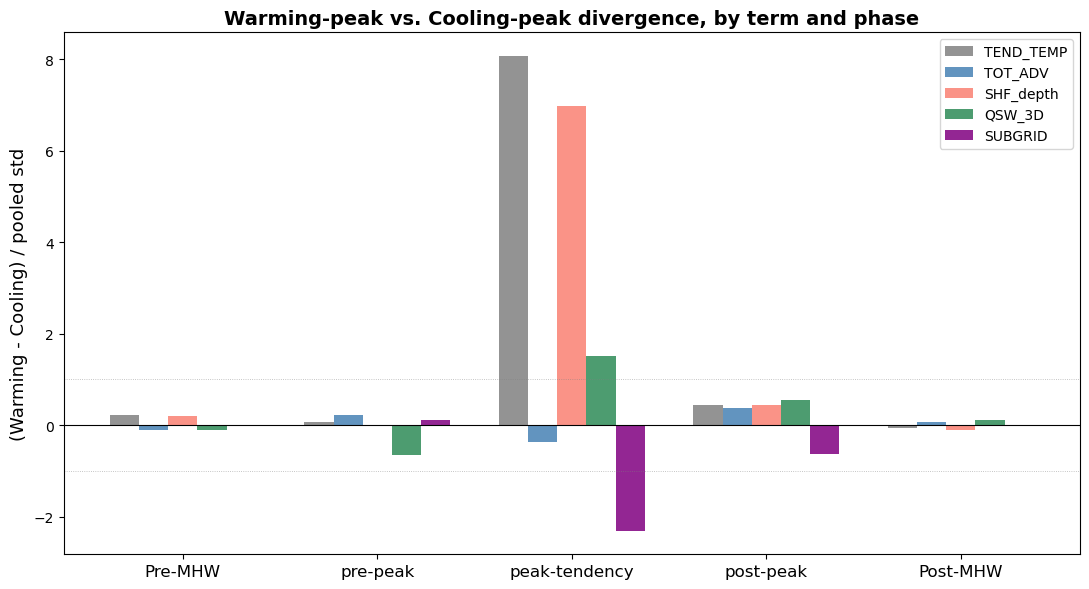

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Diff/pooled-std bar chart across phases, all terms
# ============================================================
def compute_diff_over_std(composite_warming, composite_cooling, term, phase_names):
    diffs = []
    for phase in phase_names:
        w_mean, w_std, w_n = composite_warming[term][phase]
        c_mean, c_std, c_n = composite_cooling[term][phase]
        diff = w_mean - c_mean
        pooled_std = np.sqrt((w_std**2 + c_std**2) / 2)
        diffs.append(diff / pooled_std if pooled_std > 0 else np.nan)
    return diffs

term_colors = {
    'TEND_TEMP': 'gray', 'TOT_ADV': 'steelblue',
    'SHF_depth': 'salmon', 'QSW_3D': 'seagreen', 'SUBGRID': 'purple',
}

diff_over_std = {term: compute_diff_over_std(composite_warming, composite_cooling, term, PHASE_NAMES_5) for term in TERMS}

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(PHASE_NAMES_5))
width = 0.15

for i, term in enumerate(TERMS):
    ax.bar(x + i*width, diff_over_std[term], width, label=term, color=term_colors[term], alpha=0.85)

ax.axhline(0, color='k', linewidth=0.8)
ax.axhline(1, color='gray', linewidth=0.6, linestyle=':', alpha=0.6)
ax.axhline(-1, color='gray', linewidth=0.6, linestyle=':', alpha=0.6)
ax.set_xticks(x + 2*width)
ax.set_xticklabels(PHASE_NAMES_5, fontsize=12)
ax.set_ylabel('(Warming - Cooling) / pooled std', fontsize=13)
ax.set_title('Warming-peak vs. Cooling-peak divergence, by term and phase', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.savefig('Figure_warming_cooling_divergence_bars.png', dpi=300, bbox_inches='tight')
plt.show()

In [32]:
# ============================================================
# Process heat budgets for the remaining 3 detrending methods
# ============================================================
for method in ['quadratic', 'ensmean', 'noseas']:
    output_dir_hb_method = f'/glade/derecho/scratch/cassiacai/heat_budget_profiles_by_member_{method}'
    os.makedirs(output_dir_hb_method, exist_ok=True)
    labels_full_method = da_mhwobj_labels_by_method[method]

    t0 = time.time()
    for member_id in range(100):
        save_path = f'{output_dir_hb_method}/member_{member_id}.pkl'
        if os.path.exists(save_path):
            continue
        member_profiles = process_one_member_heat_budget(
            member_id, labels_full_method, blob_analog_ids[method][member_id], NEPac_MHW_renamed_latlon
        )
        with open(save_path, 'wb') as f:
            pickle.dump(member_profiles, f)
    print(f"{method} done ({time.time()-t0:.1f}s)")

Member 0 done
Member 1 done
Member 2 done
Member 3 done
Member 4 done
Member 5 done
Member 6 done


KeyboardInterrupt: 


KeyboardInterrupt



In [34]:
# ============================================================
# Recompute shared_keys (analogs present in both canonical and time-varying results)
# ============================================================
shared_keys = set(hb_phases_all.keys()) & set(hb_phases_timevarying.keys())
print(f"Shared keys: {len(shared_keys)}")

Shared keys: 331


In [35]:
# ============================================================
# Check footprint-size volatility across ALL analogs whose peak month shifted
# ============================================================
def get_original_footprint_sizes(member_id, analog_id, labels_full):
    member_labels = labels_full.isel(ensemble_member=member_id)
    mask = (member_labels == analog_id)
    times_present = member_labels.time.where(mask.any(dim=('lat', 'lon')), drop=True)
    if len(times_present) == 0:
        return None
    return mask.sel(time=times_present).sum(dim=('lat', 'lon')).values

shifted_keys = []
for key in shared_keys:
    canon_peak = hb_phases_all[key]['peak_date']
    tv_peak = hb_phases_timevarying[key]['peak_date']
    if canon_peak is not None and tv_peak is not None and canon_peak != tv_peak:
        shifted_keys.append(key)

max_ratios = []
for member_id, analog_id in shifted_keys:
    sizes = get_original_footprint_sizes(member_id, analog_id, labels_full)
    if sizes is None or len(sizes) < 2:
        continue
    ratios = sizes[1:] / np.maximum(sizes[:-1], 1)  # month-to-month ratio
    max_ratios.append(np.max(ratios))

max_ratios = np.array(max_ratios)
print(f"Checked {len(max_ratios)} / {len(shifted_keys)} shifted analogs")
print(f"Max month-to-month footprint growth ratio: mean={max_ratios.mean():.2f}, median={np.median(max_ratios):.2f}")
print(f"Analogs with a >2x month-to-month jump: {np.sum(max_ratios > 2)} / {len(max_ratios)} "
      f"({100*np.mean(max_ratios > 2):.1f}%)")
print(f"Analogs with a >1.5x month-to-month jump: {np.sum(max_ratios > 1.5)} / {len(max_ratios)} "
      f"({100*np.mean(max_ratios > 1.5):.1f}%)")

Checked 179 / 179 shifted analogs
Max month-to-month footprint growth ratio: mean=2.48, median=2.25
Analogs with a >2x month-to-month jump: 123 / 179 (68.7%)
Analogs with a >1.5x month-to-month jump: 168 / 179 (93.9%)


In [37]:
# ============================================================
# Reload Section 3.2 analog characteristics (saved earlier)
# ============================================================
with open('/glade/derecho/scratch/cassiacai/section_3_2_analog_data.pkl', 'rb') as f:
    save_bundle = pickle.load(f)

all_analog_characteristics = save_bundle['all_analog_characteristics']
blob_fosi_characteristics = save_bundle['blob_fosi_characteristics']

print(f"Loaded {len(all_analog_characteristics)} analog characteristics -- VERIFY: 331")

Loaded 331 analog characteristics -- VERIFY: 331


In [38]:
# ============================================================
# Are the boundary-case (excluded) analogs physically different from the rest?
# ============================================================
prepeak_missing_warming = [k for k in warming_keys if np.isnan(hb_phases_all[k]['phases']['TEND_TEMP']['pre-peak'])]
postpeak_missing_cooling = [k for k in cooling_keys if np.isnan(hb_phases_all[k]['phases']['TEND_TEMP']['post-peak'])]

def compare_characteristics(excluded_keys, all_group_keys, all_analog_characteristics, label):
    included_keys = [k for k in all_group_keys if k not in excluded_keys]
    print(f"\n=== {label}: excluded (n={len(excluded_keys)}) vs. included (n={len(included_keys)}) ===")
    for char in ['duration', 'intensity_max', 'extent_max']:
        excl_vals = [all_analog_characteristics[k][char] for k in excluded_keys if k in all_analog_characteristics]
        incl_vals = [all_analog_characteristics[k][char] for k in included_keys if k in all_analog_characteristics]
        if len(excl_vals) > 0 and len(incl_vals) > 0:
            print(f"  {char}: excluded mean={np.mean(excl_vals):.2f}, included mean={np.mean(incl_vals):.2f}")

compare_characteristics(prepeak_missing_warming, warming_keys, all_analog_characteristics, "Warming-peak, pre-peak-missing")
compare_characteristics(postpeak_missing_cooling, cooling_keys, all_analog_characteristics, "Cooling-peak, post-peak-missing")


=== Warming-peak, pre-peak-missing: excluded (n=28) vs. included (n=85) ===
  duration: excluded mean=13.57, included mean=17.07
  intensity_max: excluded mean=4.11, included mean=3.90
  extent_max: excluded mean=18515021.49, included mean=20063928.24

=== Cooling-peak, post-peak-missing: excluded (n=36) vs. included (n=93) ===
  duration: excluded mean=12.53, included mean=15.74
  intensity_max: excluded mean=3.92, included mean=4.03
  extent_max: excluded mean=19557201.34, included mean=20064892.71


In [39]:
import numpy as np

# ============================================================
# Permutation test: warming vs. cooling difference, per term/phase,
# with Benjamini-Hochberg FDR correction across all 25 comparisons
# ============================================================
def permutation_test_diff(vals_warming, vals_cooling, n_perm=10000, seed=0):
    """Two-sided permutation test for difference in means between two groups."""
    rng = np.random.default_rng(seed)
    observed_diff = np.mean(vals_warming) - np.mean(vals_cooling)
    combined = np.concatenate([vals_warming, vals_cooling])
    n_warm = len(vals_warming)

    perm_diffs = np.empty(n_perm)
    for i in range(n_perm):
        rng.shuffle(combined)
        perm_diffs[i] = np.mean(combined[:n_warm]) - np.mean(combined[n_warm:])

    p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
    return observed_diff, p_value


def benjamini_hochberg(p_values, alpha=0.05):
    """Returns boolean array of which hypotheses are significant under BH-FDR correction."""
    p_values = np.array(p_values)
    n = len(p_values)
    order = np.argsort(p_values)
    ranked_p = p_values[order]
    thresholds = (np.arange(1, n + 1) / n) * alpha
    below = ranked_p <= thresholds
    if not below.any():
        return np.zeros(n, dtype=bool)
    max_rank = np.max(np.where(below)[0])
    significant = np.zeros(n, dtype=bool)
    significant[order[:max_rank + 1]] = True
    return significant


# ============================================================
# Run across all 25 term x phase combinations
# ============================================================
results = []
for term in TERMS:
    for phase in PHASE_NAMES_5:
        vals_w = np.array(get_individual_values_by_phase(warming_keys, hb_phases_all, term, [phase])[phase])
        vals_c = np.array(get_individual_values_by_phase(cooling_keys, hb_phases_all, term, [phase])[phase])
        if len(vals_w) < 2 or len(vals_c) < 2:
            continue
        diff, p = permutation_test_diff(vals_w, vals_c, n_perm=10000)
        results.append({'term': term, 'phase': phase, 'diff': diff, 'p_raw': p})

p_raw_values = [r['p_raw'] for r in results]
significant_bh = benjamini_hochberg(p_raw_values, alpha=0.05)

print(f"{'Term':<12} {'Phase':<15} {'Diff':>8} {'p_raw':>8} {'Sig (BH)':>10}")
for r, sig in zip(results, significant_bh):
    print(f"{r['term']:<12} {r['phase']:<15} {r['diff']:>8.2f} {r['p_raw']:>8.4f} {str(sig):>10}")

n_sig = sum(significant_bh)
print(f"\n{n_sig} / {len(results)} comparisons significant after BH-FDR correction (alpha=0.05)")

Term         Phase               Diff    p_raw   Sig (BH)
TEND_TEMP    Pre-MHW             0.21   0.0822      False
TEND_TEMP    pre-peak            0.03   0.6424      False
TEND_TEMP    peak-tendency       4.89   0.0000       True
TEND_TEMP    post-peak           0.26   0.0014       True
TEND_TEMP    Post-MHW           -0.05   0.6345      False
TOT_ADV      Pre-MHW            -0.11   0.4481      False
TOT_ADV      pre-peak            0.17   0.0898      False
TOT_ADV      peak-tendency      -0.61   0.0075       True
TOT_ADV      post-peak           0.34   0.0084       True
TOT_ADV      Post-MHW            0.08   0.5980      False
SHF_depth    Pre-MHW             0.36   0.1078      False
SHF_depth    pre-peak            0.00   0.9976      False
SHF_depth    peak-tendency       9.31   0.0000       True
SHF_depth    post-peak           0.55   0.0015       True
SHF_depth    Post-MHW           -0.15   0.4685      False
QSW_3D       Pre-MHW            -0.04   0.4613      False
QSW_3D       p

In [43]:
import pickle

with open('analog_mld_results.pkl', 'rb') as f:
    all_analog_mld = pickle.load(f)

print(f"Loaded {len(all_analog_mld)} analogs with MLD -- VERIFY: 331")

Loaded 331 analogs with MLD -- VERIFY: 331


In [44]:
sample_keys = list(all_analog_mld.keys())[:20]
for key in sample_keys:
    member_id, analog_id = key
    canonical_mean = all_analog_mld[key]['mld_mean']
    print(f"{key}: canonical mld_mean={canonical_mean:.1f}")

(0, 28.0): canonical mld_mean=35.1
(0, 43.0): canonical mld_mean=40.1
(0, 58.0): canonical mld_mean=56.4
(0, 85.0): canonical mld_mean=40.0
(1, 49.0): canonical mld_mean=43.8
(1, 75.0): canonical mld_mean=64.3
(2, 56.0): canonical mld_mean=55.3
(2, 59.0): canonical mld_mean=62.8
(2, 66.0): canonical mld_mean=54.6
(2, 80.0): canonical mld_mean=39.1
(3, 5.0): canonical mld_mean=62.3
(3, 47.0): canonical mld_mean=62.0
(3, 67.0): canonical mld_mean=62.5
(4, 4.0): canonical mld_mean=57.3
(4, 34.0): canonical mld_mean=59.7
(4, 50.0): canonical mld_mean=58.7
(4, 88.0): canonical mld_mean=55.8
(4, 98.0): canonical mld_mean=45.2
(5, 3.0): canonical mld_mean=41.3
(5, 36.0): canonical mld_mean=48.1


In [46]:
# ============================================================
# Check what regridder is actually producing
# ============================================================
test_mask = build_time_varying_mask_for_analog(
    labels_full.isel(ensemble_member=0), 28.0,
    labels_full.isel(ensemble_member=0).time.where(
        (labels_full.isel(ensemble_member=0) == 28.0).any(dim=('lat','lon')), drop=True
    ),
    regridder
)
print("Current regridder output shape:", test_mask.sizes)
print("Expected: nlat_t=163 (matching hb_cropped/hmxl_combined)")

Current regridder output shape: Frozen({'time': 4, 'nlat_t': 384, 'nlon_t': 320})
Expected: nlat_t=163 (matching hb_cropped/hmxl_combined)


In [47]:
# ============================================================
# Rebuild regridder from the CROPPED POP grid, explicitly
# ============================================================
pop_grid_ref = xr.open_dataset('/glade/derecho/scratch/cassiacai/mean_image_3_POP.nc')
pop_grid_ref_cropped = pop_grid_ref.isel(nlat=lat_slice, nlon=lon_slice).rename({'nlat': 'nlat_t', 'nlon': 'nlon_t'})
print("Cropped POP grid shape:", pop_grid_ref_cropped.TLAT.shape, "-- expect (163, ...)")

regridder = build_labels_to_pop_regridder(
    labels_full.isel(ensemble_member=0, time=0),
    pop_grid_ref_cropped
)

# Re-verify
test_mask = build_time_varying_mask_for_analog(
    labels_full.isel(ensemble_member=0), 28.0,
    labels_full.isel(ensemble_member=0).time.where(
        (labels_full.isel(ensemble_member=0) == 28.0).any(dim=('lat','lon')), drop=True
    ),
    regridder
)
print("Rebuilt regridder output shape:", test_mask.sizes, "-- expect nlat_t=163")

Cropped POP grid shape: (163, 90) -- expect (163, ...)
Rebuilt regridder output shape: Frozen({'time': 4, 'nlat_t': 163, 'nlon_t': 90}) -- expect nlat_t=163


In [49]:
def compute_mld_timevarying_for_analog(member_id, analog_id, labels_full, regridder):
    """MLD averaged over the analog's own regridded tracked footprint."""
    member_labels = labels_full.isel(ensemble_member=member_id)
    mask = (member_labels == analog_id)
    times_present = member_labels.time.where(mask.any(dim=('lat', 'lon')), drop=True)
    if len(times_present) == 0:
        return None

    ds_hist, ds_fut = afuncs.get_ds_var(
        '/glade/campaign/cgd/cesm/CESM2-LE/ocn/proc/tseries/month_1/HMXL/', 'HMXL', 'ocn', member_id
    )
    hmxl_hist_cropped = ds_hist.HMXL.isel(nlat=lat_slice, nlon=lon_slice)
    hmxl_fut_cropped = ds_fut.HMXL.isel(nlat=lat_slice, nlon=lon_slice)
    hmxl_combined = xr.concat([hmxl_hist_cropped, hmxl_fut_cropped], dim='time').sel(
        time=slice('1979-01-01', '2020-12-01')
    ) / 100.0
    hmxl_combined = hmxl_combined.rename({'nlat': 'nlat_t', 'nlon': 'nlon_t'})

    time_varying_mask = build_time_varying_mask_for_analog(member_labels, analog_id, times_present, regridder)
    hmxl_masked = hmxl_combined.sel(time=times_present).where(time_varying_mask.sel(time=times_present) == 1)

    return float(hmxl_masked.mean()), float(hmxl_masked.max())

In [48]:
sample_keys = list(all_analog_mld.keys())[:20]
for key in sample_keys:
    member_id, analog_id = key
    canonical_mean = all_analog_mld[key]['mld_mean']
    tv_result = compute_mld_timevarying_for_analog(member_id, analog_id, labels_full, regridder)
    if tv_result is not None:
        tv_mean, tv_max = tv_result
        print(f"{key}: canonical={canonical_mean:.1f} | time-varying={tv_mean:.1f}")
    else:
        print(f"{key}: canonical={canonical_mean:.1f} | time-varying=N/A")

(0, 28.0): canonical=35.1 | time-varying=27.9
(0, 43.0): canonical=40.1 | time-varying=31.7
(0, 58.0): canonical=56.4 | time-varying=51.7
(0, 85.0): canonical=40.0 | time-varying=38.1
(1, 49.0): canonical=43.8 | time-varying=50.6
(1, 75.0): canonical=64.3 | time-varying=54.8
(2, 56.0): canonical=55.3 | time-varying=50.4
(2, 59.0): canonical=62.8 | time-varying=52.4
(2, 66.0): canonical=54.6 | time-varying=50.4
(2, 80.0): canonical=39.1 | time-varying=38.2
(3, 5.0): canonical=62.3 | time-varying=49.1
(3, 47.0): canonical=62.0 | time-varying=51.8
(3, 67.0): canonical=62.5 | time-varying=49.3
(4, 4.0): canonical=57.3 | time-varying=48.0
(4, 34.0): canonical=59.7 | time-varying=59.7
(4, 50.0): canonical=58.7 | time-varying=56.4
(4, 88.0): canonical=55.8 | time-varying=43.5
(4, 98.0): canonical=45.2 | time-varying=45.1
(5, 3.0): canonical=41.3 | time-varying=37.9
(5, 36.0): canonical=48.1 | time-varying=47.0


In [50]:
canonical_vals = np.array([all_analog_mld[k]['mld_mean'] for k in sample_keys])
tv_vals = []
for key in sample_keys:
    member_id, analog_id = key
    tv_result = compute_mld_timevarying_for_analog(member_id, analog_id, labels_full, regridder)
    tv_vals.append(tv_result[0] if tv_result is not None else np.nan)
tv_vals = np.array(tv_vals)

diffs = canonical_vals - tv_vals
pct_diffs = 100 * diffs / canonical_vals
print(f"Mean canonical - time-varying: {np.nanmean(diffs):.2f}m")
print(f"Mean % difference: {np.nanmean(pct_diffs):.1f}%")
print(f"Analogs where canonical > time-varying: {np.sum(diffs > 0)} / {len(diffs)}")

Mean canonical - time-varying: 5.53m
Mean % difference: 10.1%
Analogs where canonical > time-varying: 18 / 20


In [51]:
import os
import pickle
import time

# ============================================================
# Compute time-varying MLD for ALL 331 analogs (crash-safe, resumable)
# ============================================================
mld_timevarying_path = '/glade/derecho/scratch/cassiacai/analog_mld_timevarying_results.pkl'

if os.path.exists(mld_timevarying_path):
    with open(mld_timevarying_path, 'rb') as f:
        all_analog_mld_timevarying = pickle.load(f)
    print(f"Resuming — {len(all_analog_mld_timevarying)} already processed")
else:
    all_analog_mld_timevarying = {}

t0 = time.time()
for key in all_analog_mld.keys():
    if key in all_analog_mld_timevarying:
        continue
    member_id, analog_id = key
    tv_result = compute_mld_timevarying_for_analog(member_id, analog_id, labels_full, regridder)
    if tv_result is not None:
        tv_mean, tv_max = tv_result
        all_analog_mld_timevarying[key] = {'mld_mean': tv_mean, 'mld_max': tv_max}

    # Save every 20 analogs processed, not every single one (avoid excessive I/O)
    if len(all_analog_mld_timevarying) % 20 == 0:
        with open(mld_timevarying_path, 'wb') as f:
            pickle.dump(all_analog_mld_timevarying, f)
        print(f"  ...{len(all_analog_mld_timevarying)} done ({time.time()-t0:.1f}s elapsed)")

# Final save
with open(mld_timevarying_path, 'wb') as f:
    pickle.dump(all_analog_mld_timevarying, f)

print(f"\nDone. Total time-varying MLD computed: {len(all_analog_mld_timevarying)} -- VERIFY: 331")
print(f"Total time: {time.time()-t0:.1f}s")


# ============================================================
# Compare against canonical, full population
# ============================================================
import numpy as np

shared_mld_keys = [k for k in all_analog_mld.keys() if k in all_analog_mld_timevarying]
canonical_vals = np.array([all_analog_mld[k]['mld_mean'] for k in shared_mld_keys])
tv_vals = np.array([all_analog_mld_timevarying[k]['mld_mean'] for k in shared_mld_keys])

diffs = canonical_vals - tv_vals
pct_diffs = 100 * diffs / canonical_vals

print(f"\nn = {len(shared_mld_keys)}")
print(f"Mean canonical MLD: {canonical_vals.mean():.2f}m")
print(f"Mean time-varying MLD: {tv_vals.mean():.2f}m")
print(f"Mean (canonical - time-varying): {diffs.mean():.2f}m")
print(f"Median (canonical - time-varying): {np.median(diffs):.2f}m")
print(f"Mean % difference: {pct_diffs.mean():.1f}%")
print(f"Median % difference: {np.median(pct_diffs):.1f}%")
print(f"Analogs where canonical > time-varying: {np.sum(diffs > 0)} / {len(diffs)} ({100*np.mean(diffs>0):.1f}%)")

  ...20 done (50.0s elapsed)
  ...40 done (105.9s elapsed)
  ...60 done (165.2s elapsed)
  ...80 done (220.1s elapsed)
  ...100 done (271.9s elapsed)
  ...120 done (327.0s elapsed)
  ...140 done (380.7s elapsed)
  ...160 done (433.9s elapsed)
  ...180 done (492.2s elapsed)
  ...200 done (550.3s elapsed)
  ...220 done (610.7s elapsed)
  ...240 done (664.8s elapsed)
  ...260 done (723.4s elapsed)
  ...280 done (778.7s elapsed)
  ...300 done (834.1s elapsed)
  ...320 done (889.2s elapsed)

Done. Total time-varying MLD computed: 331 -- VERIFY: 331
Total time: 915.4s

n = 331
Mean canonical MLD: 54.78m
Mean time-varying MLD: 48.84m
Mean (canonical - time-varying): 5.94m
Median (canonical - time-varying): 6.11m
Mean % difference: 10.7%
Median % difference: 11.3%
Analogs where canonical > time-varying: 292 / 331 (88.2%)


In [52]:
# ============================================================
# Sensitivity test: how does min_months_for_5phase threshold
# affect the phase split, sample sizes, and warming/cooling counts?
# ============================================================
thresholds_to_test = [4, 5, 6, 7, 8, 9, 10, 12]

sensitivity_results = {}
for threshold in thresholds_to_test:
    hb_phases_thresh = {}
    for key, data in heat_budget_profiles_all.items():
        phases, n_phases, peak_date = phase_split_adaptive(data['terms'], min_months_for_5phase=threshold)
        hb_phases_thresh[key] = {'phases': phases, 'n_phases': n_phases, 'peak_date': peak_date}

    keys_5phase_thresh = [k for k, v in hb_phases_thresh.items() if v['n_phases'] == 5]
    warming_thresh, cooling_thresh = separate_peak_by_sign(keys_5phase_thresh, hb_phases_thresh)

    # Boundary-case counts at this threshold
    n_prepeak_missing = sum(
        1 for k in warming_thresh
        if np.isnan(hb_phases_thresh[k]['phases']['TEND_TEMP']['pre-peak'])
    )
    n_postpeak_missing = sum(
        1 for k in cooling_thresh
        if np.isnan(hb_phases_thresh[k]['phases']['TEND_TEMP']['post-peak'])
    )

    sensitivity_results[threshold] = {
        'n_3phase': len(heat_budget_profiles_all) - len(keys_5phase_thresh),
        'n_5phase': len(keys_5phase_thresh),
        'n_warming': len(warming_thresh),
        'n_cooling': len(cooling_thresh),
        'n_prepeak_missing': n_prepeak_missing,
        'n_postpeak_missing': n_postpeak_missing,
        'pct_prepeak_missing': 100 * n_prepeak_missing / len(warming_thresh) if len(warming_thresh) > 0 else np.nan,
        'pct_postpeak_missing': 100 * n_postpeak_missing / len(cooling_thresh) if len(cooling_thresh) > 0 else np.nan,
    }

print(f"{'Thresh':<8}{'3ph':<6}{'5ph':<6}{'Warm':<6}{'Cool':<6}{'PrePkMiss':<12}{'PostPkMiss':<12}")
for threshold, r in sensitivity_results.items():
    print(f"{threshold:<8}{r['n_3phase']:<6}{r['n_5phase']:<6}{r['n_warming']:<6}{r['n_cooling']:<6}"
          f"{r['n_prepeak_missing']} ({r['pct_prepeak_missing']:.1f}%){'':<3}"
          f"{r['n_postpeak_missing']} ({r['pct_postpeak_missing']:.1f}%)")

Thresh  3ph   5ph   Warm  Cool  PrePkMiss   PostPkMiss  
4       16    315   163   152   59 (36.2%)   49 (32.2%)
5       27    304   155   149   54 (34.8%)   47 (31.5%)
6       39    292   146   146   48 (32.9%)   45 (30.8%)
7       62    269   127   142   39 (30.7%)   43 (30.3%)
8       89    242   113   129   28 (24.8%)   36 (27.9%)
9       114   217   103   114   24 (23.3%)   31 (27.2%)
10      134   197   95    102   21 (22.1%)   27 (26.5%)
12      188   143   67    76    13 (19.4%)   18 (23.7%)


In [53]:
# ============================================================
# Heat budget composite sensitivity across min_months_for_5phase thresholds
# ============================================================
thresholds_to_test = [4, 5, 6, 7, 8, 9, 10, 12]

hb_sensitivity_results = {}
for threshold in thresholds_to_test:
    hb_phases_thresh = {}
    for key, data in heat_budget_profiles_all.items():
        phases, n_phases, peak_date = phase_split_adaptive(data['terms'], min_months_for_5phase=threshold)
        hb_phases_thresh[key] = {'phases': phases, 'n_phases': n_phases, 'peak_date': peak_date}

    keys_5phase_thresh = [k for k, v in hb_phases_thresh.items() if v['n_phases'] == 5]
    warming_thresh, cooling_thresh = separate_peak_by_sign(keys_5phase_thresh, hb_phases_thresh)

    composite_warming_thresh = composite_phase_group(warming_thresh, hb_phases_thresh, PHASE_NAMES_5)
    composite_cooling_thresh = composite_phase_group(cooling_thresh, hb_phases_thresh, PHASE_NAMES_5)

    hb_sensitivity_results[threshold] = {
        'warming': {term: composite_warming_thresh[term]['peak-tendency'] for term in TERMS},
        'cooling': {term: composite_cooling_thresh[term]['peak-tendency'] for term in TERMS},
    }

# ============================================================
# Print: peak-tendency composite for each term, across thresholds
# ============================================================
for term in TERMS:
    print(f"\n=== {term} @ peak-tendency, across thresholds ===")
    print(f"{'Thresh':<8}{'Warming (mean±std, n)':<30}{'Cooling (mean±std, n)':<30}")
    for threshold in thresholds_to_test:
        w_mean, w_std, w_n = hb_sensitivity_results[threshold]['warming'][term]
        c_mean, c_std, c_n = hb_sensitivity_results[threshold]['cooling'][term]
        print(f"{threshold:<8}{w_mean:>6.2f}±{w_std:<5.2f} (n={w_n:<4}){'':<5}{c_mean:>6.2f}±{c_std:<5.2f} (n={c_n:<4})")


=== TEND_TEMP @ peak-tendency, across thresholds ===
Thresh  Warming (mean±std, n)         Cooling (mean±std, n)         
4         2.13±0.58  (n=163 )      -2.56±0.69  (n=152 )
5         2.16±0.57  (n=155 )      -2.57±0.68  (n=149 )
6         2.18±0.57  (n=146 )      -2.60±0.65  (n=146 )
7         2.23±0.54  (n=127 )      -2.60±0.66  (n=142 )
8         2.25±0.55  (n=113 )      -2.64±0.66  (n=129 )
9         2.28±0.55  (n=103 )      -2.65±0.63  (n=114 )
10        2.31±0.55  (n=95  )      -2.66±0.64  (n=102 )
12        2.41±0.55  (n=67  )      -2.77±0.65  (n=76  )

=== TOT_ADV @ peak-tendency, across thresholds ===
Thresh  Warming (mean±std, n)         Cooling (mean±std, n)         
4        -0.22±1.45  (n=163 )       0.45±1.84  (n=152 )
5        -0.23±1.44  (n=155 )       0.47±1.86  (n=149 )
6        -0.20±1.45  (n=146 )       0.47±1.87  (n=146 )
7        -0.15±1.48  (n=127 )       0.47±1.86  (n=142 )
8        -0.11±1.46  (n=113 )       0.50±1.90  (n=129 )
9        -0.11±1.47  (n=103 

In [55]:
# ============================================================
# Rebuild cell_area_da (needed for extent calculations)
# ============================================================
def compute_cell_area(grid_ref, R=6371.0):
    dlat = np.deg2rad(np.mean(np.diff(grid_ref.lat.values)))
    dlon = np.deg2rad(np.mean(np.diff(grid_ref.lon.values)))
    cell_area = (R ** 2) * dlat * dlon * np.cos(np.deg2rad(grid_ref.lat))
    return xr.DataArray(cell_area.values, coords={'lat': grid_ref.lat}, dims='lat')

cell_area_da = compute_cell_area(labels_full)
print(f"Equatorial check: {float(cell_area_da.sel(lat=labels_full.lat.values[len(labels_full.lat)//2])):.1f} km^2 -- VERIFY: ~11881.4")

Equatorial check: 11881.4 km^2 -- VERIFY: ~11881.4


In [56]:
# ============================================================
# Compare peak-tendency month vs. peak SPATIAL EXTENT month
# (parallel to the earlier peak-SSTa comparison)
# ============================================================
def get_extent_profile_for_analog(member_labels, analog_id, times_present, cell_area_da, pre_post_months=2):
    """Area (extent) time series over the analog's own tracked footprint, padded window."""
    full_time_index = member_labels.time
    padded_times = build_padded_time_window(full_time_index, times_present)
    first_mask = (member_labels.sel(time=times_present[0]) == analog_id)
    last_mask = (member_labels.sel(time=times_present[-1]) == analog_id)

    extent_vals = []
    for t in padded_times.values:
        if t in times_present.values:
            m = (member_labels.sel(time=t) == analog_id)
        elif t < times_present.values[0]:
            m = first_mask
        else:
            m = last_mask
        extent_vals.append(float((m.astype(int) * cell_area_da).sum()))

    return xr.DataArray(extent_vals, dims='time', coords={'time': padded_times})


def compare_peak_tendency_vs_extent(member_labels, analog_id, term_profiles, cell_area_da,
                                     pre_post_months=2, min_months_for_5phase=8):
    mask = (member_labels == analog_id)
    times_present = member_labels.time.where(mask.any(dim=('lat', 'lon')), drop=True)
    if len(times_present) == 0:
        return None

    extent_profile = get_extent_profile_for_analog(member_labels, analog_id, times_present, cell_area_da, pre_post_months)

    n_total = len(extent_profile.time)
    core_start = pre_post_months
    core_end = n_total - pre_post_months
    if core_end - core_start < min_months_for_5phase:
        return None

    tend_temp = term_profiles['TEND_TEMP']
    core_tend = tend_temp.isel(time=slice(core_start, core_end))
    peak_tendency_idx = core_start + int(np.abs(core_tend.values).argmax())

    core_extent = extent_profile.isel(time=slice(core_start, core_end))
    peak_extent_idx = core_start + int(core_extent.values.argmax())

    return {
        'same_month': peak_tendency_idx == peak_extent_idx,
        'months_apart': peak_extent_idx - peak_tendency_idx,
    }


# ============================================================
# Run across all 5-phase analogs
# ============================================================
extent_comparison_results = {}
for member_id in range(100):
    member_labels_i = labels_full.isel(ensemble_member=member_id)
    for analog_id in blob_analog_ids['linear'][member_id]:
        key = (member_id, analog_id)
        if key not in heat_budget_profiles_all:
            continue
        result = compare_peak_tendency_vs_extent(
            member_labels_i, analog_id, heat_budget_profiles_all[key]['terms'], cell_area_da
        )
        if result is not None:
            extent_comparison_results[key] = result

print(f"Compared {len(extent_comparison_results)} five-phase analogs")
n_same = sum(1 for r in extent_comparison_results.values() if r['same_month'])
print(f"Peak-tendency month == peak-extent month: {n_same} / {len(extent_comparison_results)} "
      f"({100*n_same/len(extent_comparison_results):.1f}%)")

months_apart_extent = np.array([r['months_apart'] for r in extent_comparison_results.values()])
print(f"Mean months apart: {months_apart_extent.mean():.2f}, median: {np.median(months_apart_extent):.2f}")
print(f"Mean |months apart|: {np.abs(months_apart_extent).mean():.2f}")

Compared 242 five-phase analogs
Peak-tendency month == peak-extent month: 9 / 242 (3.7%)
Mean months apart: 0.02, median: -1.00
Mean |months apart|: 3.98


In [58]:
import json

def unflatten_climate_stats(flat_dict):
    unflattened = {}
    for flat_key, v in flat_dict.items():
        parts = flat_key.split('_')
        method = parts[0]
        member_id = int(parts[1])
        analog_id = float(parts[2])
        unflattened[(method, member_id, analog_id)] = v
    return unflattened

with open('/glade/derecho/scratch/cassiacai/climate_stats_canonical.json', 'r') as f:
    climate_stats_canonical_flat = json.load(f)
climate_stats_canonical = unflatten_climate_stats(climate_stats_canonical_flat)

print(f"Loaded {len(climate_stats_canonical)} entries (all methods combined)")

# Filter to linear method only, matching keys_5phase's key structure (member_id, analog_id)
analog_climate_stats = {
    (member_id, analog_id): v
    for (method, member_id, analog_id), v in climate_stats_canonical.items()
    if method == 'linear'
}
print(f"Linear-only: {len(analog_climate_stats)} analogs -- VERIFY: 331")

Loaded 1313 entries (all methods combined)
Linear-only: 331 analogs -- VERIFY: 331


In [59]:
# ============================================================
# Characterize 3-phase (short) vs 5-phase (long) populations
# ============================================================
keys_3phase = [k for k, v in hb_phases_all.items() if v['n_phases'] == 3]

def compare_populations(keys_a, keys_b, all_analog_characteristics, label_a, label_b):
    print(f"\n=== {label_a} (n={len(keys_a)}) vs. {label_b} (n={len(keys_b)}) ===")
    for char in ['intensity_max', 'extent_max', 'mld_mean']:
        vals_a = [all_analog_characteristics[k][char] for k in keys_a if k in all_analog_characteristics]
        vals_b = [all_analog_characteristics[k][char] for k in keys_b if k in all_analog_characteristics]
        if len(vals_a) > 0 and len(vals_b) > 0:
            print(f"  {char}: {label_a} mean={np.mean(vals_a):.2f}, {label_b} mean={np.mean(vals_b):.2f}")

compare_populations(keys_3phase, keys_5phase, all_analog_characteristics, "3-phase (short)", "5-phase (long)")

# ============================================================
# Does excluding the 89 short (3-phase) events change PDO/ENSO
# correlations or percentile results computed on "all 331"?
# ============================================================
# Using analog_climate_stats from the PDO/ENSO section (reload if needed)
for char in ['pdo_mean', 'nino34_mean']:
    all_vals = [analog_climate_stats[k][char] for k in analog_climate_stats]
    long_only_vals = [analog_climate_stats[k][char] for k in keys_5phase if k in analog_climate_stats]
    print(f"\n{char}: all-331 mean={np.mean(all_vals):.3f} | 5-phase-only mean={np.mean(long_only_vals):.3f}")


=== 3-phase (short) (n=89) vs. 5-phase (long) (n=242) ===
  intensity_max: 3-phase (short) mean=3.18, 5-phase (long) mean=3.98
  extent_max: 3-phase (short) mean=14322509.64, 5-phase (long) mean=19809705.67
  mld_mean: 3-phase (short) mean=46.47, 5-phase (long) mean=57.84

pdo_mean: all-331 mean=1.277 | 5-phase-only mean=1.189

nino34_mean: all-331 mean=1.149 | 5-phase-only mean=1.295


In [60]:
# ============================================================
# Split peak-extent comparison by warming-peak vs. cooling-peak
# ============================================================
warming_set = set(warming_keys)
cooling_set = set(cooling_keys)

months_apart_extent_warming = np.array([
    r['months_apart'] for k, r in extent_comparison_results.items() if k in warming_set
])
months_apart_extent_cooling = np.array([
    r['months_apart'] for k, r in extent_comparison_results.items() if k in cooling_set
])

for label, vals in [('Warming-peak', months_apart_extent_warming), ('Cooling-peak', months_apart_extent_cooling)]:
    print(f"\n=== {label} (n={len(vals)}) ===")
    print(f"Mean months apart: {vals.mean():.2f}")
    print(f"Median months apart: {np.median(vals):.2f}")
    print(f"Mean |months apart|: {np.abs(vals).mean():.2f}")
    n_pos = np.sum(vals > 0)
    n_neg = np.sum(vals < 0)
    n_zero = np.sum(vals == 0)
    print(f"Peak-extent AFTER peak-tendency: {n_pos} ({100*n_pos/len(vals):.1f}%)")
    print(f"Peak-extent BEFORE peak-tendency: {n_neg} ({100*n_neg/len(vals):.1f}%)")
    print(f"Same month: {n_zero} ({100*n_zero/len(vals):.1f}%)")


=== Warming-peak (n=113) ===
Mean months apart: 2.81
Median months apart: 3.00
Mean |months apart|: 4.36
Peak-extent AFTER peak-tendency: 87 (77.0%)
Peak-extent BEFORE peak-tendency: 18 (15.9%)
Same month: 8 (7.1%)

=== Cooling-peak (n=129) ===
Mean months apart: -2.41
Median months apart: -2.00
Mean |months apart|: 3.65
Peak-extent AFTER peak-tendency: 10 (7.8%)
Peak-extent BEFORE peak-tendency: 118 (91.5%)
Same month: 1 (0.8%)


# Scratch

In [20]:
import xesmf as xe

# ============================================================
# Build the labels-grid -> POP T-grid regridder (ONCE, reused for all analogs)
# ============================================================
def build_labels_to_pop_regridder(labels_grid_da, pop_target_grid_ds, method='nearest_s2d'):
    """
    Builds an xESMF regridder from the (regular lat/lon) Ocetrac labels grid
    to the native POP T-grid (nlat_t/nlon_t, with 2D TLAT/TLONG coordinates).

    Uses nearest-neighbor ('nearest_s2d') rather than bilinear, since we are
    regridding a BINARY mask -- bilinear would produce fractional values
    requiring an arbitrary re-binarization threshold.
    """
    ds_in = xr.Dataset(
        coords={'lat': labels_grid_da.lat.values, 'lon': labels_grid_da.lon.values}
    )
    ds_out = xr.Dataset(
        coords={
            'lat': (('nlat_t', 'nlon_t'), pop_target_grid_ds.TLAT.values),
            'lon': (('nlat_t', 'nlon_t'), pop_target_grid_ds.TLONG.values),
        }
    )
    regridder = xe.Regridder(ds_in, ds_out, method, periodic=True)
    return regridder


# ============================================================
# Time-varying footprint mask, regridded onto the POP heat-budget grid
# ============================================================
def build_time_varying_mask_for_analog(member_labels, analog_id, times_present, regridder):
    """
    Returns a (time, nlat_t, nlon_t) binary mask -- the analog's own tracked
    footprint at each of its active months, regridded onto the POP T-grid.
    """
    mask_lat_lon = (member_labels.sel(time=times_present) == analog_id).astype(float)
    mask_pop_grid = regridder(mask_lat_lon)
    mask_pop_grid_binary = xr.where(mask_pop_grid > 0.5, 1, 0)
    return mask_pop_grid_binary


# ============================================================
# Modified per-member heat budget processor: TIME-VARYING spatial mask
# ============================================================
def process_one_member_heat_budget_timevarying(member_id, labels_full, analog_ids_for_member, regridder):
    if not analog_ids_for_member:
        return {}
    hb_raw = load_lens_heat_budget_full(member_id)
    hb_raw['SUBGRID'] = hb_raw['TEND_TEMP'] - (hb_raw['TOT_ADV'] + hb_raw['SHF_depth'] + hb_raw['QSW_3D'])

    hb_detrended = {term: detrend_term(hb_raw[term]) for term in TERMS}
    hb_cropped = {term: da.isel(nlat_t=lat_slice, nlon_t=lon_slice) for term, da in hb_detrended.items()}

    member_labels = labels_full.isel(ensemble_member=member_id)
    member_profiles = {}
    for analog_id in analog_ids_for_member:
        key = (member_id, analog_id)
        mask = (member_labels == analog_id)
        times_present = member_labels.time.where(mask.any(dim=('lat', 'lon')), drop=True)
        if len(times_present) == 0:
            continue

        padded_times = build_padded_time_window(member_labels.time, times_present)
        time_varying_mask = build_time_varying_mask_for_analog(member_labels, analog_id, times_present, regridder)

        term_profiles = {}
        for term, da in hb_cropped.items():
            da_padded = da.sel(time=padded_times)
            masked_active = da_padded.sel(time=times_present).where(time_varying_mask.sel(time=times_present) == 1)
            first_mask = time_varying_mask.isel(time=0)
            last_mask = time_varying_mask.isel(time=-1)
            pre_times = padded_times[~padded_times.isin(times_present) & (padded_times < times_present[0])]
            post_times = padded_times[~padded_times.isin(times_present) & (padded_times > times_present[-1])]
            masked_pre = da_padded.sel(time=pre_times).where(first_mask == 1) if len(pre_times) > 0 else None
            masked_post = da_padded.sel(time=post_times).where(last_mask == 1) if len(post_times) > 0 else None

            pieces = [p for p in [masked_pre, masked_active, masked_post] if p is not None]
            full_masked = xr.concat(pieces, dim='time').sortby('time')
            term_profiles[term] = full_masked.mean(dim=('nlat_t', 'nlon_t')).compute()

        member_profiles[key] = {
            'terms': term_profiles,
            'season': pd.Timestamp(str(times_present.values[0])).month,
        }
    print(f"Member {member_id} done (time-varying)")
    return member_profiles


# # ============================================================
# # TEST on one member before running all 100
# # ============================================================
# TEST_MEMBER_ID = 0

# regridder = build_labels_to_pop_regridder(
#     labels_full.isel(ensemble_member=TEST_MEMBER_ID, time=0),
#     pop_grid_ref
# )

# t0 = time.time()
# test_profiles = process_one_member_heat_budget_timevarying(
#     TEST_MEMBER_ID, labels_full, blob_analog_ids['linear'][TEST_MEMBER_ID], regridder
# )
# print(f"Member {TEST_MEMBER_ID} time-varying: {len(test_profiles)} analogs, {time.time()-t0:.1f}s")

# sample_key = list(test_profiles.keys())[0]
# print("Time-varying TEND_TEMP:", test_profiles[sample_key]['terms']['TEND_TEMP'].values)
# if sample_key in heat_budget_profiles_all:
#     print("Canonical TEND_TEMP:  ", heat_budget_profiles_all[sample_key]['terms']['TEND_TEMP'].values)

In [21]:
output_dir_hb_timevarying = '/glade/derecho/scratch/cassiacai/heat_budget_profiles_by_member_timevarying'
os.makedirs(output_dir_hb_timevarying, exist_ok=True)

# Build the regridder ONCE (reused across all 100 members)
regridder = build_labels_to_pop_regridder(
    labels_full.isel(ensemble_member=0, time=0),
    pop_grid_ref  # confirm this is the right object once grid check above is done
)

t0 = time.time()
for member_id in range(100):
    save_path = f'{output_dir_hb_timevarying}/member_{member_id}.pkl'
    if os.path.exists(save_path):
        print(f"Member {member_id} already done, skipping")
        continue
    member_profiles = process_one_member_heat_budget_timevarying(
        member_id, labels_full, blob_analog_ids['linear'][member_id], regridder
    )
    with open(save_path, 'wb') as f:
        pickle.dump(member_profiles, f)
    print(f"Member {member_id} done ({time.time()-t0:.1f}s elapsed)")


# ============================================================
# Reload, phase-split, composite
# ============================================================
heat_budget_profiles_timevarying = {}
for member_id in range(100):
    save_path = f'{output_dir_hb_timevarying}/member_{member_id}.pkl'
    if os.path.exists(save_path):
        with open(save_path, 'rb') as f:
            heat_budget_profiles_timevarying.update(pickle.load(f))
print(f"Total time-varying analogs loaded: {len(heat_budget_profiles_timevarying)}")

hb_phases_timevarying = {}
for key, data in heat_budget_profiles_timevarying.items():
    phases, n_phases, peak_date = phase_split_adaptive(data['terms'])
    hb_phases_timevarying[key] = {'phases': phases, 'n_phases': n_phases, 'peak_date': peak_date}

keys_5phase_timevarying = [k for k, v in hb_phases_timevarying.items() if v['n_phases'] == 5]
composite_timevarying_all = composite_phase_group(keys_5phase_timevarying, hb_phases_timevarying, PHASE_NAMES_5)


# ============================================================
# Three-way comparison at peak-tendency: canonical / selection-only / spatial-averaging-only
# ============================================================
print("\n=== Three-way comparison at peak-tendency ===")
for term in TERMS:
    c_mean, c_std, c_n = composite_all_5phase[term]['peak-tendency']
    s_mean, s_std, s_n = composite_noncanonical_all[term]['peak-tendency']
    t_mean, t_std, t_n = composite_timevarying_all[term]['peak-tendency']
    print(f"{term}: canonical(n={c_n})={c_mean:.2f}\u00b1{c_std:.2f} | "
          f"non-canon-selection(n={s_n})={s_mean:.2f}\u00b1{s_std:.2f} | "
          f"time-varying-spatial(n={t_n})={t_mean:.2f}\u00b1{t_std:.2f}")

Member 0 already done, skipping
Member 1 already done, skipping
Member 2 already done, skipping
Member 3 already done, skipping
Member 4 already done, skipping
Member 5 already done, skipping
Member 6 already done, skipping
Member 7 already done, skipping
Member 8 already done, skipping
Member 9 already done, skipping
Member 10 already done, skipping
Member 11 already done, skipping
Member 12 already done, skipping
Member 13 already done, skipping
Member 14 already done, skipping
Member 15 already done, skipping
Member 16 already done, skipping
Member 17 already done, skipping
Member 18 already done, skipping
Member 19 already done, skipping
Member 20 already done, skipping
Member 21 already done, skipping
Member 22 already done, skipping
Member 23 already done, skipping
Member 24 already done, skipping
Member 25 already done, skipping
Member 26 already done, skipping
Member 27 already done, skipping
Member 28 already done, skipping
Member 29 already done, skipping
Member 30 already do

In [22]:
# ============================================================
# Test the time-varying regridding pipeline on ONE member first
# ============================================================
TEST_MEMBER_ID = 0

# You'll need to supply the actual POP grid reference with 2D TLAT/TLONG
# matching your cropped nlat_t/nlon_t tile -- substitute the correct file/variable:
pop_grid_ref = xr.open_dataset('/glade/derecho/scratch/cassiacai/mean_image_3_POP.nc')
# CHECK: does this file have TLAT/TLONG as coordinates or data variables?
print(list(pop_grid_ref.coords))
print(list(pop_grid_ref.data_vars))

regridder = build_labels_to_pop_regridder(
    labels_full.isel(ensemble_member=TEST_MEMBER_ID, time=0),
    pop_grid_ref  # or whatever the correct grid-reference object turns out to be
)

t0 = time.time()
test_profiles = process_one_member_heat_budget_timevarying(
    TEST_MEMBER_ID, labels_full, blob_analog_ids['linear'][TEST_MEMBER_ID], regridder
)
print(f"Member {TEST_MEMBER_ID} time-varying: {len(test_profiles)} analogs, {time.time()-t0:.1f}s")

# Sanity check: compare one analog's canonical vs. time-varying profile side by side
sample_key = list(test_profiles.keys())[0]
print("Time-varying TEND_TEMP:", test_profiles[sample_key]['terms']['TEND_TEMP'].values)
# Compare against the canonical version for the same key, if already loaded:
if sample_key in heat_budget_profiles_all:
    print("Canonical TEND_TEMP:  ", heat_budget_profiles_all[sample_key]['terms']['TEND_TEMP'].values)

['ULONG', 'ULAT', 'TLONG', 'TLAT']
['__xarray_dataarray_variable__']


AlignmentError: cannot reindex or align along dimension 'nlat_t' because of conflicting dimension sizes: {384, 163} (note: an index is found along that dimension with size=163)

In [ ]:
import xesmf as xe

# ============================================================
# Build the labels-grid -> POP T-grid regridder (ONCE, reused for all analogs)
# ============================================================
def build_labels_to_pop_regridder(labels_grid_da, pop_target_grid_ds, method='nearest_s2d'):
    """
    Builds an xESMF regridder from the (regular lat/lon) Ocetrac labels grid
    to the native POP T-grid (nlat_t/nlon_t, with 2D TLAT/TLONG coordinates),
    the reverse direction of regrid_SMYLE (which goes POP -> regular lat/lon).

    labels_grid_da: any DataArray on the labels grid (e.g. labels_full.isel(ensemble_member=0, time=0)),
                    used only for its 'lat'/'lon' coordinate values.
    pop_target_grid_ds: a Dataset/DataArray with 2D TLAT/TLONG coordinates matching
                        your cropped heat-budget nlat_t/nlon_t tile.

    Uses nearest-neighbor ('nearest_s2d') rather than bilinear, since we are
    regridding a BINARY mask -- bilinear would produce fractional values
    requiring an arbitrary re-binarization threshold.
    """
    ds_in = xr.Dataset(
        coords={'lat': labels_grid_da.lat.values, 'lon': labels_grid_da.lon.values}
    )
    ds_out = xr.Dataset(
        coords={
            'lat': (('nlat_t', 'nlon_t'), pop_target_grid_ds.TLAT.values),
            'lon': (('nlat_t', 'nlon_t'), pop_target_grid_ds.TLONG.values),
        }
    )
    regridder = xe.Regridder(ds_in, ds_out, method, periodic=True)
    return regridder


# ============================================================
# Time-varying footprint mask, regridded onto the POP heat-budget grid,
# for ONE analog's full active-month window (built once, applied to all months)
# ============================================================
def build_time_varying_mask_for_analog(member_labels, analog_id, times_present, regridder):
    """
    Returns a (time, nlat_t, nlon_t) binary mask -- the analog's own tracked
    footprint at each of its active months, regridded onto the POP T-grid.
    """
    mask_lat_lon = (member_labels.sel(time=times_present) == analog_id).astype(float)
    mask_pop_grid = regridder(mask_lat_lon)
    mask_pop_grid_binary = xr.where(mask_pop_grid > 0.5, 1, 0)  # re-binarize post-regrid
    return mask_pop_grid_binary


# ============================================================
# Modified per-member heat budget processor: TIME-VARYING spatial mask
# instead of the fixed canonical mask
# ============================================================
def process_one_member_heat_budget_timevarying(member_id, labels_full, analog_ids_for_member, regridder):
    if not analog_ids_for_member:
        return {}
    hb_raw = load_lens_heat_budget_full(member_id)
    hb_raw['SUBGRID'] = hb_raw['TEND_TEMP'] - (hb_raw['TOT_ADV'] + hb_raw['SHF_depth'] + hb_raw['QSW_3D'])

    hb_detrended = {term: detrend_term(hb_raw[term]) for term in TERMS}
    hb_cropped = {term: da.isel(nlat_t=lat_slice, nlon_t=lon_slice) for term, da in hb_detrended.items()}

    member_labels = labels_full.isel(ensemble_member=member_id)
    member_profiles = {}
    for analog_id in analog_ids_for_member:
        key = (member_id, analog_id)
        mask = (member_labels == analog_id)
        times_present = member_labels.time.where(mask.any(dim=('lat', 'lon')), drop=True)
        if len(times_present) == 0:
            continue

        padded_times = build_padded_time_window(member_labels.time, times_present)

        # Time-varying mask regridded onto POP grid, for the analog's ACTIVE months only
        # (pre/post-MHW padding months use the FIRST/LAST active-month footprint,
        # matching how the canonical version handles pre/post padding via a fixed region)
        time_varying_mask = build_time_varying_mask_for_analog(member_labels, analog_id, times_present, regridder)

        term_profiles = {}
        for term, da in hb_cropped.items():
            da_padded = da.sel(time=padded_times)
            # Active months: use the time-varying mask; pad months: use first/last active mask
            masked_active = da_padded.sel(time=times_present).where(time_varying_mask.sel(time=times_present) == 1)
            first_mask = time_varying_mask.isel(time=0)
            last_mask = time_varying_mask.isel(time=-1)
            pre_times = padded_times[~padded_times.isin(times_present) & (padded_times < times_present[0])]
            post_times = padded_times[~padded_times.isin(times_present) & (padded_times > times_present[-1])]
            masked_pre = da_padded.sel(time=pre_times).where(first_mask == 1) if len(pre_times) > 0 else None
            masked_post = da_padded.sel(time=post_times).where(last_mask == 1) if len(post_times) > 0 else None

            pieces = [p for p in [masked_pre, masked_active, masked_post] if p is not None]
            full_masked = xr.concat(pieces, dim='time').sortby('time')
            term_profiles[term] = full_masked.mean(dim=('nlat_t', 'nlon_t')).compute()

        member_profiles[key] = {
            'terms': term_profiles,
            'season': pd.Timestamp(str(times_present.values[0])).month,
        }
    print(f"Member {member_id} done (time-varying)")
    return member_profiles